# Import libraries

In [1]:
!git clone https://github.com/mcordts/cityscapesScripts.git

Cloning into 'cityscapesScripts'...
remote: Enumerating objects: 674, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 674 (delta 195), reused 184 (delta 163), pack-reused 427 (from 1)
Receiving objects: 100% (674/674), 837.07 KiB | 16.41 MiB/s, done.
Resolving deltas: 100% (381/381), done.


In [2]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

import torch
import torch.optim as optim
import torch.nn.functional as F
import torch.optim.lr_scheduler as lr_scheduler
# import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

from torchvision.io import decode_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
import torchvision.transforms.v2 as T

from cityscapesScripts.cityscapesscripts.helpers.labels import id2label, trainId2label, labels, name2label

# Helper functions

In [3]:
class_id_to_name = {}
class_id_to_color = {}
for l in labels:
    if l[2] != 255 and l[2] != -1:
        class_id_to_name[l[2]] = l[0]
        class_id_to_color[l[2]] = l[-1]
class_id_to_color[255] = (0, 0, 0)

def convert_instance_to_semantic(instance_masks, instance_labels):
    """
    Converts an instance mask of shape [N, H, W] to a semantic mask of shape [H, W].
    
    This is done by "painting" the class ID from instance_labels onto the
    corresponding binary mask from instance_masks.
    """
    if instance_masks.ndim != 3 or instance_labels.ndim != 1:
        raise ValueError(f"Expected shapes [N, H, W] and [N], but got "
                         f"{instance_masks.shape} and {instance_labels.shape}")
    
    # Reshape labels to [N, 1, 1] to allow broadcasting
    reshaped_labels = instance_labels.view(-1, 1, 1)
    
    # Multiply masks by their labels and take the max to handle overlaps
    # The result is a single [H, W] tensor where each pixel has the class ID
    semantic_mask = torch.max(instance_masks.float() * reshaped_labels, dim=0)[0]
    
    return semantic_mask.long()

def convert_instance_to_semantic_strict(instance_masks: torch.Tensor, instance_labels: torch.Tensor,
                                 image_size: tuple = (512, 1024), num_classes: int = 20, ignore_index: int = 255,
                                 background_class_id: int = 0) -> torch.Tensor:
    """
    Converts instance masks and labels to a single semantic segmentation map.
    Handles cases where no instances are found.

    Args:
        instance_masks (torch.Tensor): Tensor of instance masks, shape [N, 1, H, W] or [N, H, W].
        instance_labels (torch.Tensor): Tensor of instance labels, shape [N].
        image_size (tuple): (H, W) of the original image.
        num_classes (int): Total number of semantic classes (used for sanity, not direct output).
                           Note: Your Cityscapes labels might include 0 as a valid class.
                           Ensure background_class_id aligns with your dataset's conventions.
        background_class_id (int): The class ID to use for background/no detections.
                                   This should typically be a valid class ID, often 0.

    Returns:
        torch.Tensor: Semantic segmentation map, shape [H, W], with class IDs.
                      The class IDs will be in range [0, num_classes-1] (or background_class_id).
    """
    H, W = image_size
    # Initialize with the background class ID. This is crucial when no instances are found.
    semantic_map = torch.full((H, W), fill_value=background_class_id, dtype=torch.long, device=instance_masks.device)

    if instance_masks.shape[0] == 0: # No instances detected
        return semantic_map

    # Ensure masks are [N, H, W]
    if instance_masks.dim() == 4 and instance_masks.shape[1] == 1:
        instance_masks = instance_masks.squeeze(1) # [N, 1, H, W] -> [N, H, W]
    elif instance_masks.dim() != 3: # [N, H, W]
        raise ValueError(f"Expected instance_masks to be [N, 1, H, W] or [N, H, W]. Got {instance_masks.shape}")

    # If instance_masks and instance_labels are sorted by confidence, processing from highest confidence first
    # would make sense for overlapping regions if you want the highest confidence object to "win".
    for mask, label in zip(instance_masks, instance_labels):
        # Assuming model outputs probabilities/logits for masks, thresholding is needed.
        if label.item() != ignore_index: 
             semantic_map[mask > 0.5] = label.item()

    return semantic_map


def colorize_mask(mask, color_dict):
    """Converts a HxW segmentation mask of class indices to a 3xHxW RGB image."""
    # Ensure mask is on CPU and is a numpy array
    mask_np = mask.cpu().numpy()
    rgb_mask = np.zeros((mask_np.shape[0], mask_np.shape[1], 3), dtype=np.uint8)
    
    present_classes = np.unique(mask_np)
    
    for class_id in present_classes:
        if class_id in color_dict:
            indices = (mask_np == class_id)
            # Assign the corresponding color
            rgb_mask[indices] = color_dict[class_id]
            
    return torch.from_numpy(rgb_mask).permute(2, 0, 1)

# Config

In [4]:
from omegaconf import OmegaConf

def load_config(filepath):
    with open(filepath, 'r') as f:
        return OmegaConf.load(f)
    

path_cfg = load_config("/kaggle/input/segment-city/path_config.yaml")
train_cfg = load_config("/kaggle/input/segment-city/train_config.yaml")
model_cfg = load_config("/kaggle/input/segment-city/model_config.yaml")

In [5]:
path_cfg.dataset_path = "/kaggle/input/cityscapes/Cityscapes"
config = OmegaConf.merge(path_cfg, train_cfg, model_cfg)

config.device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Custom dataset

In [6]:
id_to_trainId_map = np.array([label.trainId for label in labels])
    
class CityscapesDataset(Dataset):
    def __init__(self, config, transform=None, split='train'):
        super().__init__()
        self.images = [] # path to leftImg8bit
        self.label_images = [] # path to labels images
        self.config = config
        self._transform = transform
        
        self.class_names = [label.category for label in labels]

        left8bit_path = os.path.join(self.config.dataset_path, "leftImg8bit", split)
        for city in os.listdir(left8bit_path):
            city_images = list(os.listdir(os.path.join(left8bit_path, city)))
            city_images = [os.path.join(left8bit_path, city, image) for image in city_images]
            self.images.extend(city_images)
            
        for city in os.listdir(os.path.join(self.config.dataset_path, self.config.type, split)):
            city_dir = os.path.join(self.config.dataset_path, self.config.type, split, city)
            for file in os.listdir(city_dir):
                if file.endswith("labelIds.png"):
                    self.label_images.append(os.path.join(city_dir, file))

        self.images = sorted(self.images)
        self.label_images = sorted(self.label_images)
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = decode_image(str(self.images[idx]))

        target = self._get_semantic_item(idx)
        
        if self._transform:
            img = self._transform(img)

        target = T.Resize((img.shape[1], img.shape[2]))(target)
        target = id_to_trainId_map[np.array(target)]
        
        return img, target

    def _get_semantic_item(self, idx):
        mask = decode_image(str(self.label_images[idx])) # Shape: [1, H, W]
        return mask

        # converted_mask = torch.full_like(mask, 0) 
        # converted_mask[mask == -1] = 0
        # valid_pixels = (mask >= 0) & (mask <= 33)
        # converted_mask[valid_pixels] = id_to_trainId_map[mask[valid_pixels]]

        # obj_ids = torch.unique(converted_mask).to(dtype=torch.uint8)
        # converted_mask = (converted_mask == obj_ids[:, None, None]).to(dtype=torch.long)
        # boxes = masks_to_boxes(converted_mask)
        # labels = obj_ids[:, None].to(dtype=torch.int64)
        # iscrowd = torch.zeros((len(labels),), dtype=torch.int64)
        
        # widths = boxes[:, 2] - boxes[:, 0]
        # heights = boxes[:, 3] - boxes[:, 1]
        # valid_boxes_mask = (widths > 0) & (heights > 0)

        # boxes = boxes[valid_boxes_mask]
        # converted_mask = converted_mask[valid_boxes_mask]
        # labels = labels[valid_boxes_mask]
        # iscrowd = iscrowd[valid_boxes_mask] 

        # target = {}
        # target["masks"] = tv_tensors.Mask(converted_mask) # Shape: [H, W]
        # target["labels"] = labels.squeeze(1) 
        # target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=T.functional.get_size(img))
        # target["iscrowd"] = iscrowd
        # target["area"] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # return tv_tensors.Image(img), target

(3, 512, 1024)
(1, 512, 1024)


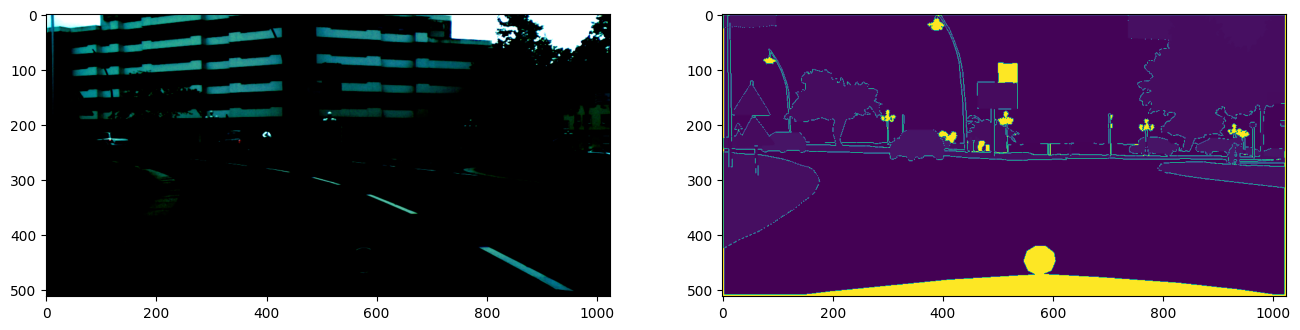

In [7]:
train_augmentation_deeplab = T.Compose([
    T.Resize((512,1024)),
    T.RandomHorizontalFlip(),
    # T.RandomSolarize(threshold=20.0),
    T.RandomGrayscale(p=0.2),
    # T.GaussianBlur(kernel_size=7, sigma=(0.1, 2.0)),
    T.ToImage(), T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) 
val_augmentation_deeplab = T.Compose([
    T.Resize((512,1024)),
    T.ToImage(), T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CityscapesDataset(path_cfg, val_augmentation_deeplab)
img, target = train_dataset[0]
img = np.array(img)
print(img.shape)
print(target.shape)


plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.imshow(img.transpose(1, 2, 0))
# print(target["labels"])
plt.subplot(122)
plt.imshow(target.transpose(1, 2, 0))
# print(target["masks"].shape)
# print(target["labels"])
# plt.imshow(target["masks"][3], alpha=0.9)

In [8]:
# def collate_fn(batch):
#     """
#     Since the number of objects varies per image, we collate the images and targets
#     into lists. The model expects a list of images and a list of targets dictionaries.
#     """
#     # batch is a list of tuples: [(img1, target1), (img2, target2), ...]
#     images = [item[0] for item in batch] # This will be a list of image tensors/tv_tensors.Image
#     targets = [item[1] for item in batch] # This will be a list of target dictionaries
#     return images, targets

def get_dataloader(dataset, config, is_train=True):
    dataloader = DataLoader(dataset, batch_size=(config.per_gpu_train_batch_size if is_train else config.per_gpu_eval_batch_size), num_workers=config.num_workers, shuffle=is_train)
    return dataloader

In [9]:
def show_loss_graph(losses):
    plt.figure(figsize=(12,8))
    plt.title("Loss over training")
    plt.plot(losses, color='b', linewidth=2)
    
    plt.xlabel("steps")
    plt.ylabel("loss value")
    plt.xlim(0, len(losses)-1)
    
    plt.grid()
    plt.legend()
    plt.show()

def show_lr_graph(lrs):
    plt.figure(figsize=(12,8))
    plt.title("Learning rate over training")
    plt.plot(lrs, color='r', linewidth=2)
    
    plt.xlabel("steps")
    plt.ylabel("learning rate")
    plt.xlim(0, len(lrs)-1)
    
    plt.grid()
    plt.legend()
    plt.show()

# DeepLab

## Backbone (MobileNet + ResNet)

In [10]:
from torch import nn
try: # for torchvision<0.4
    from torchvision.models.utils import load_state_dict_from_url
except: # for torchvision>=0.4
    from torch.hub import load_state_dict_from_url
import torch.nn.functional as F

__all__ = ['MobileNetV2', 'mobilenet_v2']


model_urls = {
    'mobidlenet_v2': 'https://download.pytorch.org/models/mobilenet_v2-b0353104.pth',
}


def _make_divisible(v, divisor, min_value=None):
    """
    This function is taken from the original tf repo.
    It ensures that all layers have a channel number that is divisible by 8
    It can be seen here:
    https://github.com/tensorflow/models/blob/master/research/slim/nets/mobilenet/mobilenet.py
    :param v:
    :param divisor:
    :param min_value:
    :return:
    """
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    # Make sure that round down does not go down by more than 10%.
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


class ConvBNReLU(nn.Sequential):
    def __init__(self, in_planes, out_planes, kernel_size=3, stride=1, dilation=1, groups=1):
        #padding = (kernel_size - 1) // 2
        super(ConvBNReLU, self).__init__(
            nn.Conv2d(in_planes, out_planes, kernel_size, stride, 0, dilation=dilation, groups=groups, bias=False),
            nn.BatchNorm2d(out_planes),
            nn.ReLU6(inplace=True)
        )

def fixed_padding(kernel_size, dilation):
    kernel_size_effective = kernel_size + (kernel_size - 1) * (dilation - 1)
    pad_total = kernel_size_effective - 1
    pad_beg = pad_total // 2
    pad_end = pad_total - pad_beg
    return (pad_beg, pad_end, pad_beg, pad_end) 

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, dilation, expand_ratio):
        super(InvertedResidual, self).__init__()
        self.stride = stride
        assert stride in [1, 2]

        hidden_dim = int(round(inp * expand_ratio))
        self.use_res_connect = self.stride == 1 and inp == oup

        layers = []
        if expand_ratio != 1:
            # pw
            layers.append(ConvBNReLU(inp, hidden_dim, kernel_size=1))

        layers.extend([
            # dw
            ConvBNReLU(hidden_dim, hidden_dim, stride=stride, dilation=dilation, groups=hidden_dim),
            # pw-linear
            nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
            nn.BatchNorm2d(oup),
        ])
        self.conv = nn.Sequential(*layers)

        self.input_padding = fixed_padding( 3, dilation )

    def forward(self, x):
        x_pad = F.pad(x, self.input_padding)
        if self.use_res_connect:
            return x + self.conv(x_pad)
        else:
            return self.conv(x_pad)

class MobileNetV2(nn.Module):
    def __init__(self, num_classes=1000, output_stride=8, width_mult=1.0, inverted_residual_setting=None, round_nearest=8):
        """
        MobileNet V2 main class

        Args:
            num_classes (int): Number of classes
            width_mult (float): Width multiplier - adjusts number of channels in each layer by this amount
            inverted_residual_setting: Network structure
            round_nearest (int): Round the number of channels in each layer to be a multiple of this number
            Set to 1 to turn off rounding
        """
        super(MobileNetV2, self).__init__()
        block = InvertedResidual
        input_channel = 32
        last_channel = 1280
        self.output_stride = output_stride
        current_stride = 1
        if inverted_residual_setting is None:
            inverted_residual_setting = [
                # t, c, n, s
                [1, 16, 1, 1],
                [6, 24, 2, 2],
                [6, 32, 3, 2],
                [6, 64, 4, 2],
                [6, 96, 3, 1],
                [6, 160, 3, 2],
                [6, 320, 1, 1],
            ]

        # only check the first element, assuming user knows t,c,n,s are required
        if len(inverted_residual_setting) == 0 or len(inverted_residual_setting[0]) != 4:
            raise ValueError("inverted_residual_setting should be non-empty "
                             "or a 4-element list, got {}".format(inverted_residual_setting))

        # building first layer
        input_channel = _make_divisible(input_channel * width_mult, round_nearest)
        self.last_channel = _make_divisible(last_channel * max(1.0, width_mult), round_nearest)
        features = [ConvBNReLU(3, input_channel, stride=2)]
        current_stride *= 2
        dilation=1
        previous_dilation = 1

        # building inverted residual blocks
        for t, c, n, s in inverted_residual_setting:
            output_channel = _make_divisible(c * width_mult, round_nearest)
            previous_dilation = dilation
            if current_stride == output_stride:
                stride = 1
                dilation *= s
            else:
                stride = s
                current_stride *= s
            output_channel = int(c * width_mult)

            for i in range(n):
                if i==0:
                    features.append(block(input_channel, output_channel, stride, previous_dilation, expand_ratio=t))
                else:
                    features.append(block(input_channel, output_channel, 1, dilation, expand_ratio=t))
                input_channel = output_channel
        # building last several layers
        features.append(ConvBNReLU(input_channel, self.last_channel, kernel_size=1))
        # make it nn.Sequential
        self.features = nn.Sequential(*features)

        # building classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.last_channel, num_classes),
        )

        # weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = x.mean([2, 3])
        x = self.classifier(x)
        return x


def mobilenet_v2(pretrained=False, progress=True, **kwargs):
    """
    Constructs a MobileNetV2 architecture from
    `"MobileNetV2: Inverted Residuals and Linear Bottlenecks" <https://arxiv.org/abs/1801.04381>`_.

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    model = MobileNetV2(**kwargs)
    if pretrained:
        state_dict = load_state_dict_from_url(model_urls['mobilenet_v2'],
                                              progress=progress)
        model.load_state_dict(state_dict)
    return model

In [11]:
import torch
import torch.nn as nn
try: # for torchvision<0.4
    from torchvision.models.utils import load_state_dict_from_url
except: # for torchvision>=0.4
    from torch.hub import load_state_dict_from_url


__all__ = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
           'resnet152', 'resnext50_32x4d', 'resnext101_32x8d',
           'wide_resnet50_2', 'wide_resnet101_2']

model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
    'resnext50_32x4d': 'https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth',
    'resnext101_32x8d': 'https://download.pytorch.org/models/resnext101_32x8d-8ba56ff5.pth',
    'wide_resnet50_2': 'https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth',
    'wide_resnet101_2': 'https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth',
}


def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, groups=groups, bias=False, dilation=dilation)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError('BasicBlock only supports groups=1 and base_width=64')
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(Bottleneck, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False,
                 groups=1, width_per_group=64, replace_stride_with_dilation=None,
                 norm_layer=None):
        super(ResNet, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError("replace_stride_with_dilation should be None "
                             "or a 3-element tuple, got {}".format(replace_stride_with_dilation))
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2,
                                       dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2,
                                       dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2,
                                       dilate=replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, self.groups,
                            self.base_width, previous_dilation, norm_layer))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups,
                                base_width=self.base_width, dilation=self.dilation,
                                norm_layer=norm_layer))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


def _resnet(arch, block, layers, pretrained, progress, **kwargs):
    model = ResNet(block, layers, **kwargs)
    if pretrained:
        state_dict = load_state_dict_from_url(model_urls[arch],
                                              progress=progress)
        model.load_state_dict(state_dict)
    return model


def resnet18(pretrained=False, progress=True, **kwargs):
    r"""ResNet-18 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet18', BasicBlock, [2, 2, 2, 2], pretrained, progress,
                   **kwargs)


def resnet34(pretrained=False, progress=True, **kwargs):
    r"""ResNet-34 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet34', BasicBlock, [3, 4, 6, 3], pretrained, progress,
                   **kwargs)


def resnet50(pretrained=False, progress=True, **kwargs):
    r"""ResNet-50 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet50', Bottleneck, [3, 4, 6, 3], pretrained, progress,
                   **kwargs)


def resnet101(pretrained=False, progress=True, **kwargs):
    r"""ResNet-101 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet101', Bottleneck, [3, 4, 23, 3], pretrained, progress,
                   **kwargs)


def resnet152(pretrained=False, progress=True, **kwargs):
    r"""ResNet-152 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet152', Bottleneck, [3, 8, 36, 3], pretrained, progress,
                   **kwargs)


def resnext50_32x4d(pretrained=False, progress=True, **kwargs):
    r"""ResNeXt-50 32x4d model from
    `"Aggregated Residual Transformation for Deep Neural Networks" <https://arxiv.org/pdf/1611.05431.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['groups'] = 32
    kwargs['width_per_group'] = 4
    return _resnet('resnext50_32x4d', Bottleneck, [3, 4, 6, 3],
                   pretrained, progress, **kwargs)


def resnext101_32x8d(pretrained=False, progress=True, **kwargs):
    r"""ResNeXt-101 32x8d model from
    `"Aggregated Residual Transformation for Deep Neural Networks" <https://arxiv.org/pdf/1611.05431.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['groups'] = 32
    kwargs['width_per_group'] = 8
    return _resnet('resnext101_32x8d', Bottleneck, [3, 4, 23, 3],
                   pretrained, progress, **kwargs)


def wide_resnet50_2(pretrained=False, progress=True, **kwargs):
    r"""Wide ResNet-50-2 model from
    `"Wide Residual Networks" <https://arxiv.org/pdf/1605.07146.pdf>`_

    The model is the same as ResNet except for the bottleneck number of channels
    which is twice larger in every block. The number of channels in outer 1x1
    convolutions is the same, e.g. last block in ResNet-50 has 2048-512-2048
    channels, and in Wide ResNet-50-2 has 2048-1024-2048.

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['width_per_group'] = 64 * 2
    return _resnet('wide_resnet50_2', Bottleneck, [3, 4, 6, 3],
                   pretrained, progress, **kwargs)


def wide_resnet101_2(pretrained=False, progress=True, **kwargs):
    r"""Wide ResNet-101-2 model from
    `"Wide Residual Networks" <https://arxiv.org/pdf/1605.07146.pdf>`_

    The model is the same as ResNet except for the bottleneck number of channels
    which is twice larger in every block. The number of channels in outer 1x1
    convolutions is the same, e.g. last block in ResNet-50 has 2048-512-2048
    channels, and in Wide ResNet-50-2 has 2048-1024-2048.

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['width_per_group'] = 64 * 2
    return _resnet('wide_resnet101_2', Bottleneck, [3, 4, 23, 3],
                   pretrained, progress, **kwargs)

## ASPP

In [12]:
import torch
from torch import nn
from torch.nn import functional as F

class _SimpleSegmentationModel(nn.Module):
    def __init__(self, backbone, classifier):
        super(_SimpleSegmentationModel, self).__init__()
        self.backbone = backbone
        self.classifier = classifier
        
    def forward(self, x):
        input_shape = x.shape[-2:]
        features = self.backbone(x)
        x = self.classifier(features)
        x = F.interpolate(x, size=input_shape, mode='bilinear', align_corners=False)
        return x


class DeepLabV3(_SimpleSegmentationModel):
    """
    Implements DeepLabV3 model from
    `"Rethinking Atrous Convolution for Semantic Image Segmentation"
    <https://arxiv.org/abs/1706.05587>`_.

    Arguments:
        backbone (nn.Module): the network used to compute the features for the model.
            The backbone should return an OrderedDict[Tensor], with the key being
            "out" for the last feature map used, and "aux" if an auxiliary classifier
            is used.
        classifier (nn.Module): module that takes the "out" element returned from
            the backbone and returns a dense prediction.
        aux_classifier (nn.Module, optional): auxiliary classifier used during training
    """
    pass

class DeepLabHeadV3Plus(nn.Module):
    def __init__(self, in_channels, low_level_channels, num_classes, aspp_dilate=[12, 24, 36]):
        super(DeepLabHeadV3Plus, self).__init__()
        self.project = nn.Sequential( 
            nn.Conv2d(low_level_channels, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )

        self.aspp = ASPP(in_channels, aspp_dilate)

        self.classifier = nn.Sequential(
            nn.Conv2d(304, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1)
        )
        self._init_weight()

    def forward(self, feature):
        low_level_feature = self.project( feature['low_level'] )
        output_feature = self.aspp(feature['out'])
        output_feature = F.interpolate(output_feature, size=low_level_feature.shape[2:], mode='bilinear', align_corners=False)
        return self.classifier( torch.cat( [ low_level_feature, output_feature ], dim=1 ) )
    
    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

class DeepLabHead(nn.Module):
    def __init__(self, in_channels, num_classes, aspp_dilate=[12, 24, 36]):
        super(DeepLabHead, self).__init__()

        self.classifier = nn.Sequential(
            ASPP(in_channels, aspp_dilate),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1)
        )
        self._init_weight()

    def forward(self, feature):
        return self.classifier( feature['out'] )

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

class AtrousSeparableConvolution(nn.Module):
    """ Atrous Separable Convolution
    """
    def __init__(self, in_channels, out_channels, kernel_size,
                            stride=1, padding=0, dilation=1, bias=True):
        super(AtrousSeparableConvolution, self).__init__()
        self.body = nn.Sequential(
            # Separable Conv
            nn.Conv2d( in_channels, in_channels, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, bias=bias, groups=in_channels ),
            # PointWise Conv
            nn.Conv2d( in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=bias),
        )
        
        self._init_weight()

    def forward(self, x):
        return self.body(x)

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

class ASPPConv(nn.Sequential):
    def __init__(self, in_channels, out_channels, dilation):
        modules = [
            nn.Conv2d(in_channels, out_channels, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        super(ASPPConv, self).__init__(*modules)

class ASPPPooling(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        size = x.shape[-2:]
        x = super().forward(x)
        return F.interpolate(x, size=size, mode='bilinear', align_corners=False)

class ASPP(nn.Module):
    def __init__(self, in_channels, atrous_rates):
        super(ASPP, self).__init__()
        out_channels = 256
        modules = []
        modules.append(nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)))

        rate1, rate2, rate3 = tuple(atrous_rates)
        modules.append(ASPPConv(in_channels, out_channels, rate1))
        modules.append(ASPPConv(in_channels, out_channels, rate2))
        modules.append(ASPPConv(in_channels, out_channels, rate3))
        modules.append(ASPPPooling(in_channels, out_channels))

        self.convs = nn.ModuleList(modules)

        self.project = nn.Sequential(
            nn.Conv2d(5 * out_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),)

    def forward(self, x):
        res = []
        for conv in self.convs:
            res.append(conv(x))
        res = torch.cat(res, dim=1)
        return self.project(res)



def convert_to_separable_conv(module):
    new_module = module
    if isinstance(module, nn.Conv2d) and module.kernel_size[0]>1:
        new_module = AtrousSeparableConvolution(module.in_channels,
                                      module.out_channels, 
                                      module.kernel_size,
                                      module.stride,
                                      module.padding,
                                      module.dilation,
                                      module.bias)
    for name, child in module.named_children():
        new_module.add_module(name, convert_to_separable_conv(child))
    return new_module

## Get backbone

In [13]:
from collections import OrderedDict


class IntermediateLayerGetter(nn.ModuleDict):
    """
    Module wrapper that returns intermediate layers from a model

    It has a strong assumption that the modules have been registered
    into the model in the same order as they are used.
    This means that one should **not** reuse the same nn.Module
    twice in the forward if you want this to work.

    Additionally, it is only able to query submodules that are directly
    assigned to the model. So if `model` is passed, `model.feature1` can
    be returned, but not `model.feature1.layer2`.

    Arguments:
        model (nn.Module): model on which we will extract the features
        return_layers (Dict[name, new_name]): a dict containing the names
            of the modules for which the activations will be returned as
            the key of the dict, and the value of the dict is the name
            of the returned activation (which the user can specify).

    Examples::

        >>> m = torchvision.models.resnet18(pretrained=True)
        >>> # extract layer1 and layer3, giving as names `feat1` and feat2`
        >>> new_m = torchvision.models._utils.IntermediateLayerGetter(m,
        >>>     {'layer1': 'feat1', 'layer3': 'feat2'})
        >>> out = new_m(torch.rand(1, 3, 224, 224))
        >>> print([(k, v.shape) for k, v in out.items()])
        >>>     [('feat1', torch.Size([1, 64, 56, 56])),
        >>>      ('feat2', torch.Size([1, 256, 14, 14]))]
    """
    def __init__(self, model, return_layers):
        if not set(return_layers).issubset([name for name, _ in model.named_children()]):
            raise ValueError("return_layers are not present in model")

        orig_return_layers = return_layers
        return_layers = {k: v for k, v in return_layers.items()}
        layers = OrderedDict()
        for name, module in model.named_children():
            layers[name] = module
            if name in return_layers:
                del return_layers[name]
            if not return_layers:
                break

        super(IntermediateLayerGetter, self).__init__(layers)
        self.return_layers = orig_return_layers

    def forward(self, x):
        out = OrderedDict()
        for name, module in self.named_children():
            x = module(x)

            if name in self.return_layers:
                out_name = self.return_layers[name]
                out[out_name] = x
                
        return out

## Deeplabv3 and deeplabv3+

In [14]:
tmp = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
           'resnet152', 'resnext50_32x4d', 'resnext101_32x8d',
           'wide_resnet50_2', 'wide_resnet101_2', 'MobileNetV2', 'mobilenet_v2']

model_urls = {
    'mobilenet_v2': 'https://download.pytorch.org/models/mobilenet_v2-b0353104.pth',
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
    'resnext50_32x4d': 'https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth',
    'resnext101_32x8d': 'https://download.pytorch.org/models/resnext101_32x8d-8ba56ff5.pth',
    'wide_resnet50_2': 'https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth',
    'wide_resnet101_2': 'https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth',
}


In [15]:
def deeplabv3_resnet(deeplab_name, backbone_name, n_classes, output_stride, pretrained_backbone):
    if output_stride==8:
        replace_stride_with_dilation=[False, True, True]
        aspp_dilate = [12, 24, 36]
    else:
        replace_stride_with_dilation=[False, False, True]
        aspp_dilate = [6, 12, 18]

    # backbone = Resnet.__dict__[backbone_name](
    #     pretrained = pretrained_backbone,
    #     replace_stride_with_dilation = reaplce_stride_with_dilation
    # )
    backbone = tmp[backbone_name](
        pretrained = pretrained_backbone,
        replace_stride_with_dilation = reaplce_stride_with_dilation
    )

    inplanes = 2048
    low_level_planes = 256
    if deeplab_name == "deeplabv3":
        return_layers = {"layer4": "out"}
        classifier = DeepLabHead(inplanes, n_classes, aspp_dilate)
    elif deeplab_name == "deeplabv3plus":
        return_layers = {"layer4": "out", "layer1": "low_level"}
        classifier = DeepLabHeadV3Plus(inplanes, low_level_planes, n_classes, aspp_dilate)
        
    backbone = IntermediateLayerGetter(backbone, return_layers = return_layers)
    model = DeepLabV3(backbone, classifier)
    return model

def deeplabv3_mobilenet(deeplab_name, backbone_name, n_classes, output_stride, pretrained_backbone):
    if output_stride==8:
        aspp_dilate = [12, 24, 36]
    else:
        aspp_dilate = [6, 12, 18]

    backbone = mobilenet_v2(pretrained = pretrained_backbone, output_stride = output_stride)
    # backbone = mobilenetv2.mobilenet_v2(pretrained = pretrained_backbone, output_stride = output_stride)
    backbone.low_level_features = backbone.features[0:4]
    backbone.high_level_features = backbone.features[4:-1]
    backbone.features = None
    backbone.classifier = None

    inplanes = 320
    low_level_planes = 24
    if deeplab_name == "deeplabv3":
        return_layers = {"high_level_features": "out"}
        classifier = DeepLabHead(inplanes, n_classes, aspp_dilate)
    elif deeplab_name == "deeplabv3plus":
        return_layers = {"high_level_features": "out", "low_level_features": "low_level"}
        classifier = DeepLabHeadV3Plus(inplanes, low_level_planes, n_classes, aspp_dilate)
        
    backbone = IntermediateLayerGetter(backbone, return_layers = return_layers)
    model = DeepLabV3(backbone, classifier)
    return model

def build_DeepLabv3(full_name, num_classes=19, output_stride=8, pretrained_backbone=True):
    deeplab_name, backbone_name = full_name.split("_")
    # print(deeplab_name, backbone_name)
    assert deeplab_name == "deeplabv3" or deeplab_name == "deeplabv3plus"
    assert backbone_name.startswith("resnet") or backbone_name.startswith("mobilenet"), "Supported backbone: mobilenet, resnet50, resnet101"
    if backbone_name.startswith("resnet"):
        assert backbone_name == "resnet50" or backbone_name == "resnet101", "Supported backbone: mobilenet, resnet50, resnet101"
        return deeplabv3_resnet(deeplab_name, backbone_name, num_classes, output_stride, pretrained_backbone)
    else:
        return deeplabv3_mobilenet(deeplab_name, backbone_name, num_classes, output_stride, pretrained_backbone)

In [16]:
def build_model(model_config, num_channels=3, num_classes=20, output_stride=8):
    if model_config.model_name.lower() == "unet":
        return UNET(num_channels, num_classes)
    elif model_config.model_name.lower() == "maskrcnn":
        return build_MaskRCNN(num_classes)
    elif model_config.model_name.lower().startswith("deeplabv3"):
        assert "_" in model_config.model_name.lower(), "A backbone should be specified for deeplabv3"
        return build_DeepLabv3(model_config.model_name.lower(), num_classes, output_stride, True)
    else:
        print(f"{model_config.model_name} is currently not supported")

# Train DeepLab

In [17]:
class FocalLoss(nn.Module):
    def __init__(self, ignore_index=0, alpha=0.25, gamma=2, reduction='mean'):
        super().__init__()
        self.ignore_index = ignore_index
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        inputs: Logits from model (B, C, H, W).
        targets: Ground truth masks (B, H, W).
        """
        if targets.size() == 4 and targets.shape[1] == 1:
            targets = targets.squeeze(1).long()

        CE_loss = F.cross_entropy(inputs, targets, reduction=self.reduction, ignore_index=self.ignore_index)
        # focal loss = BCE * a * (1 - e^(-BCE))^y 
        pt = torch.exp(-CE_loss) 
        focal_loss = self.alpha * (1 - pt) ** self.gamma * CE_loss

        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

In [18]:
class_id_to_name_19c = {}
class_id_to_color_19c = {}
id_to_trainId_map_19c = torch.zeros((34,), dtype=torch.long)
for label in labels:
    if 0 <= label.id <= 33:
        id_to_trainId_map_19c[label.id] = label.trainId

for l in labels:
    class_id_to_name_19c[l[2]] = l[0]
    class_id_to_color_19c[l[2]] = l[-1]


In [19]:
import random
def visualize_deeplab(deeplab_model, dataset, class_id_to_name, class_id_to_color, idx=None, device='cpu'):
    """
    Loads a sample, runs inference, and displays the original image,
    ground truth mask, and predicted mask side-by-side.
    """
    
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)
    original_image_viz = T.Resize((512, 1024))(decode_image(dataset.images[idx]))
    deeplab_model.eval()

    with torch.no_grad():
        # 1. Get data from the dataset
        image_tensor, target_mask = dataset[idx]
    
        gt_semantic_mask = torch.tensor(target_mask).squeeze(0)
    
        # 2. Prepare image for the model and run inference
        input_tensor = image_tensor.unsqueeze(0).to(device, dtype=torch.float32)
        logits = deeplab_model(input_tensor)
        
        # 3. Process the prediction: Use argmax (this part was already correct)
        pred_semantic_mask = torch.argmax(logits.squeeze(0), dim=0).cpu()
    
    # Colorize the ground truth and prediction masks
    gt_color_mask = colorize_mask(gt_semantic_mask, class_id_to_color)
    pred_color_mask = colorize_mask(pred_semantic_mask, class_id_to_color)
    
    # 5. Display the results
    plt.figure(figsize=(24, 8))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original_image_viz.permute(1, 2, 0))
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt_color_mask.permute(1, 2, 0))
    plt.title("Ground Truth")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_color_mask.permute(1, 2, 0))
    plt.title("DeepLab Prediction")
    plt.axis('off')
    
    plt.show()
    deeplab_model.train()

In [20]:
test_dataset_for_viz = CityscapesDataset(path_cfg, transform=val_augmentation_deeplab, split='val')
# visualize_deeplab(deeplab_model, test_dataset_for_viz, class_id_to_name_19c, class_id_to_color_19c)

In [21]:
import time
def train_deeplab_semantic(model, train_dataset, config):
    n_total = len(train_dataset) * config.n_epochs
    model.to(config.device)
    model.train()

    train_dataloader = get_dataloader(train_dataset, config)
    optimizer = optim.AdamW(model.parameters(), lr=config.optimizer.params.lr, eps=config.optimizer.params.eps, weight_decay=config.optimizer.params.weight_decay)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.99, patience=20, cooldown=5, min_lr=5e-5)
    # scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_total, eta_min=1e-5)
    # optimizer = torch.optim.SGD(params=[
    #     {'params': model.backbone.parameters(), 'lr': 0.1 * config.optimizer.params.lr},
    #     {'params': model.classifier.parameters(), 'lr': config.optimizer.params.lr},
    # ], lr=config.optimizer.params.lr, momentum=0.9, weight_decay=config.optimizer.params.weight_decay)
    # scheduler = lr_scheduler.PolynomialLR(optimizer, total_iters=n_total, power=0.9)
    if config.loss_fn == "cross_entropy":
        criterion = nn.CrossEntropyLoss(ignore_index=255, reduction='mean')
    elif config.loss_fn == "focal_loss":
        criterion = FocalLoss(ignore_index=255, reduction='mean')

    scaler = None
    if config.scaler:
        scaler = torch.amp.GradScaler(config.device, enabled=True)
    step_losses = []
    lrs = []
    
    iter_times = []
    mem_usages = []
    
    total_train_start_time = time.time()
    
    with tqdm(total=n_total, unit="step") as pbar:
        for epoch in range(1, config.n_epochs+1):
            epoch_loss = 0.0
            for batch in train_dataloader:
                iter_start_time = time.time()
                if torch.cuda.is_available():
                    torch.cuda.reset_peak_memory_stats(config.device)
                    
                images, targets = batch
                images = images.to(config.device, dtype=torch.float32)
                # if len(iter_times)*2 >= 2970 and len(iter_times)*2 <= 2980: 
                #     asd1.append(images)
                #     asd2.append(targets)
                targets = targets.to(config.device, dtype=torch.long)
                
                with torch.amp.autocast(device_type=config.device, enabled=(scaler is not None)):
                    predicted_logits = model(images)
                    loss_value = criterion(predicted_logits, targets.squeeze(1))
                    
                optimizer.zero_grad()
                if scaler is not None:
                    scaler.scale(loss_value).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss_value.backward()
                    optimizer.step()
                    
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler_metric = loss_value.item()
                    scheduler.step(scheduler_metric)
                else:
                    scheduler.step()

                step_losses.append(loss_value.half().item())
                lrs.append(scheduler.get_last_lr()[0])
                epoch_loss += loss_value.item()

                # --- METRICS TRACKING ---
                train_time_s_iter = time.time() - iter_start_time
                iter_times.append(train_time_s_iter)
                if torch.cuda.is_available():
                    train_mem_gb = torch.cuda.max_memory_allocated(config.device) / (1024 ** 3)
                    mem_usages.append(train_mem_gb)
                else:
                    train_mem_gb = 0.0
                
                pbar.update(len(images))
                pbar.set_postfix(
                    current_loss=f"{loss_value.item():.4f}",
                    avg_loss=f"{sum(step_losses)/len(step_losses):.4f}",
                    lr=f"{scheduler.get_last_lr()[0]:.1e}",
                    mem_gb=f"{train_mem_gb:.2f}",
                    time_s_iter=f"{train_time_s_iter:.2f}"
                )


            epoch_loss /= len(train_dataloader)
            print(f"Epoch {epoch}/{config.n_epochs+1} loss: {epoch_loss}")
            visualize_deeplab(model, test_dataset_for_viz, class_id_to_name_19c, class_id_to_color_19c, idx=None, device=config.device)

    # --- Training Time Calculation ---
    total_train_time_s = time.time() - total_train_start_time
    total_train_time_hr = total_train_time_s / 3600
    avg_train_time_s_iter = sum(iter_times) / len(iter_times)
    avg_train_mem_gb = sum(mem_usages) / len(mem_usages) if len(mem_usages) > 0 else 0


    # --- INFERENCE TIMING (INDEPENDENT OF TRAINING LOOP) ---
    print("\n--- Measuring Inference Speed ---")
    model.eval()
    inference_model_times = []
    inference_total_times = []
    num_inference_samples = 100
    num_warmup_samples = 5

    with torch.no_grad():
        # Warm-up runs
        print(f"Performing {num_warmup_samples} warm-up runs...")
        for i in range(num_warmup_samples):
            image_for_inference, _ = test_dataset_for_viz[i]
            image_tensor = image_for_inference.to(config.device, dtype=torch.float32).unsqueeze(0)
            _ = model(image_tensor)

        # Timed runs
        print(f"Measuring over {num_inference_samples} samples...")
        for i in range(num_inference_samples):
            image_for_inference, _ = test_dataset_for_viz[i]

            inf_total_start_time = time.time()
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            inf_model_start_time = time.time()

            image_tensor = image_for_inference.to(config.device, dtype=torch.float32).unsqueeze(0)
            _ = model(image_tensor)

            if torch.cuda.is_available():
                torch.cuda.synchronize()
            inf_model_end_time = time.time()
            inf_total_end_time = time.time()

            inference_model_times.append(inf_model_end_time - inf_model_start_time)
            inference_total_times.append(inf_total_end_time - inf_total_start_time)

    avg_inference_model_time_s_im = np.mean(inference_model_times)
    avg_inference_total_time_s_im = np.mean(inference_total_times)


    # --- FINAL METRICS REPORT ---
    print("\n--- Training & Inference Summary ---")
    print(f"| train mem (GB)             | {avg_train_mem_gb:.2f}")
    print(f"| train time (s/iter)        | {avg_train_time_s_iter:.4f}")
    print(f"| total train time (hr)      | {total_train_time_hr:.4f}")
    print(f"| inference model time (s/im)| {avg_inference_model_time_s_im:.4f}")
    print(f"| inference total time (s/im)| {avg_inference_total_time_s_im:.4f}")
    print("------------------------------------\n")
    
    torch.save({
        'epoch': config.n_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'step_losses': step_losses,
    }, os.path.join(config.ckpt_path, f"{config.model_name}_ckpt_{config.n_epochs}epoch.pth"))
    show_loss_graph(step_losses)
    show_lr_graph(lrs)
    return model, step_losses

In [22]:
# # if args.type == "full":
# #     id_to_trainId_map = id_to_trainId_map_20c
# #     num_classes = 20
# # else:
# #     id_to_trainId_map = id_to_trainId_map_9c
# #     num_classes = 9
# config.model_name = "deeplabv3_mobilenet"
# config.scaler = 'amp'
# config.ckpt_path = "/kaggle/working/"
# config.optimizer.params.lr = 1e-3
# config.optimizer.params.weight_decay = 1e-4
# config.output_stride = 8
# config.per_gpu_train_batch_size = 2
# config.loss_fn = "cross_entropy"
# config.n_epochs = 10
# # config.separable_conv = True # plus only
# deeplab_model = build_model(config, num_classes=19, output_stride=config.output_stride)
# train_dataset = CityscapesDataset(config, transform=train_augmentation_deeplab, split='train')
# test_dataset_for_viz = CityscapesDataset(config)

In [23]:
# deeplab_model, _ = train_deeplab_semantic(deeplab_model, train_dataset, config)

In [26]:

config.model_name = "deeplabv3_mobilenet"
config.scaler = 'amp'
config.ckpt_path = "/kaggle/working/"
config.optimizer.params.lr = 1e-3
config.optimizer.params.weight_decay = 1e-4
config.output_stride = 8
config.per_gpu_train_batch_size = 4 # batch size is the problem...
config.loss_fn = "focal_loss"
config.n_epochs = 8
# config.separable_conv = True # plus only
deeplab_model2 = build_model(config, num_classes=19, output_stride=config.output_stride)
train_dataset = CityscapesDataset(config, transform=train_augmentation_deeplab, split='train')
test_dataset_for_viz = CityscapesDataset(config)

 12%|█▎        | 2975/23800 [05:39<39:30,  8.78step/s, avg_loss=0.0880, current_loss=0.0642, lr=7.8e-04, mem_gb=3.60, time_s_iter=0.33]

Epoch 1/9 loss: 0.08798368207319208


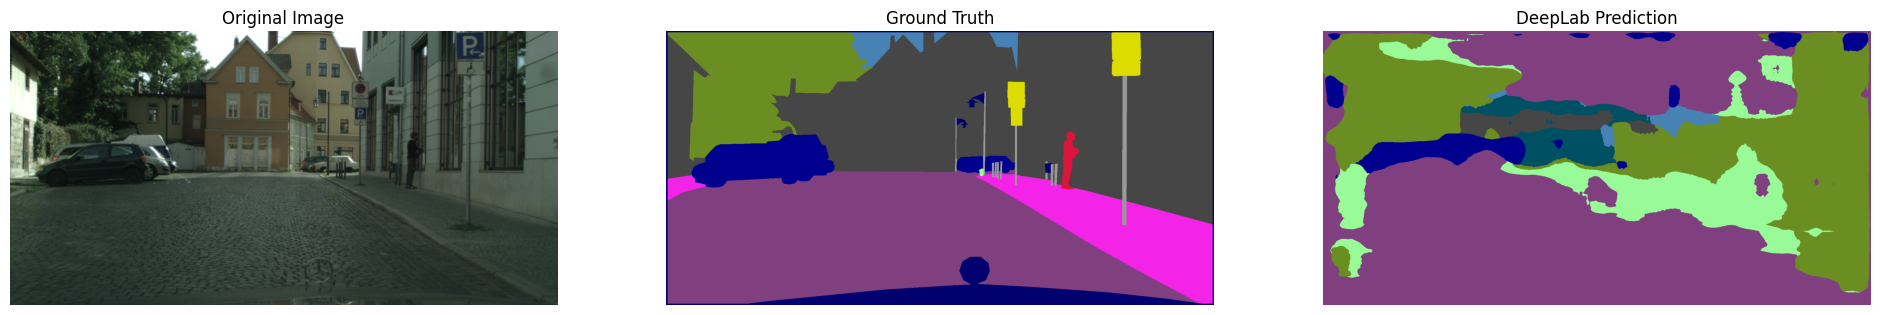

 25%|██▌       | 5950/23800 [11:19<33:40,  8.84step/s, avg_loss=0.0709, current_loss=0.0125, lr=5.9e-04, mem_gb=3.60, time_s_iter=0.33]  

Epoch 2/9 loss: 0.05377824381381894


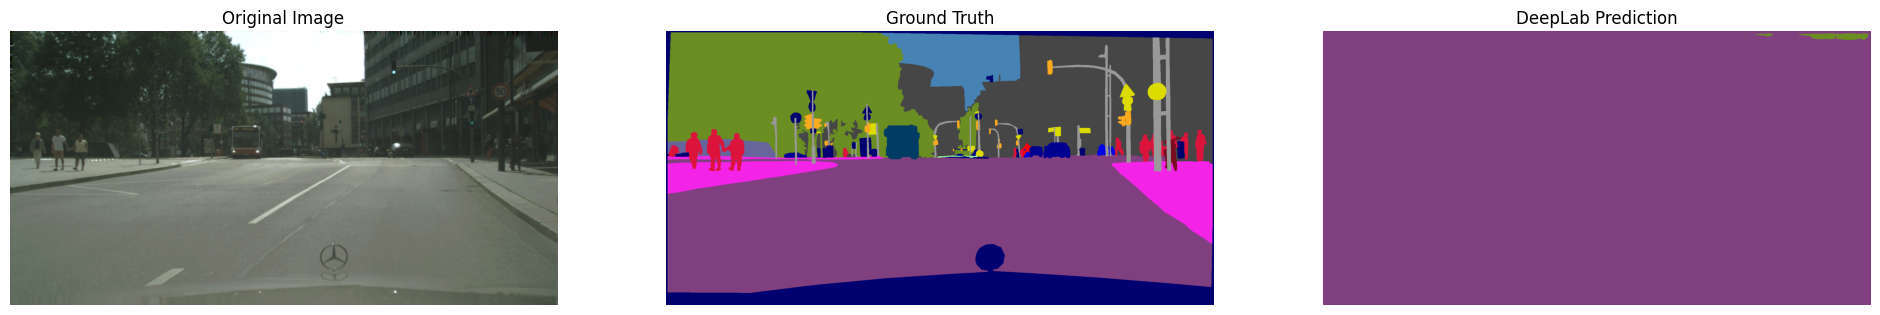

 38%|███▊      | 8925/23800 [16:59<28:01,  8.85step/s, avg_loss=0.0592, current_loss=0.0185, lr=4.5e-04, mem_gb=3.60, time_s_iter=0.33]  

Epoch 3/9 loss: 0.03577402739983392


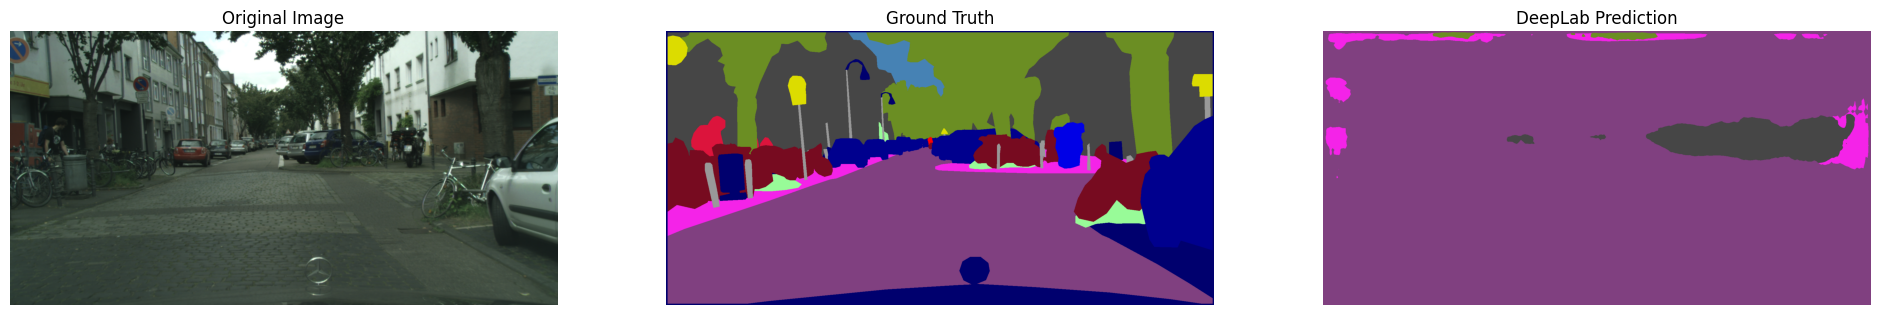

 50%|█████     | 11900/23800 [22:39<22:25,  8.84step/s, avg_loss=0.0515, current_loss=0.0837, lr=3.4e-04, mem_gb=3.60, time_s_iter=0.33] 

Epoch 4/9 loss: 0.02860088399248398


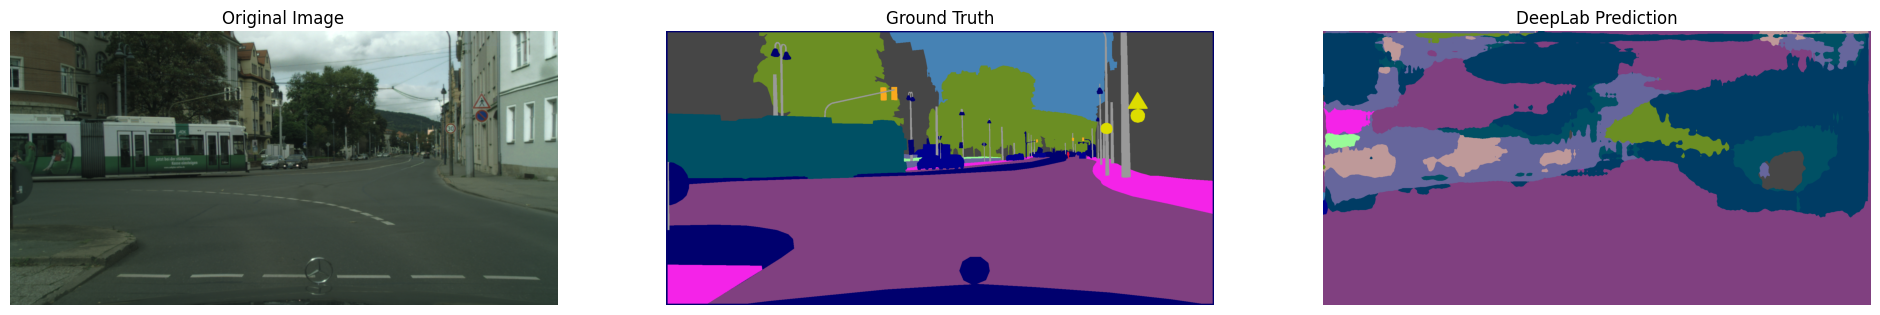

 62%|██████▎   | 14875/23800 [28:19<16:48,  8.85step/s, avg_loss=0.0462, current_loss=0.0367, lr=2.5e-04, mem_gb=3.60, time_s_iter=0.33]  

Epoch 5/9 loss: 0.025091830636650044


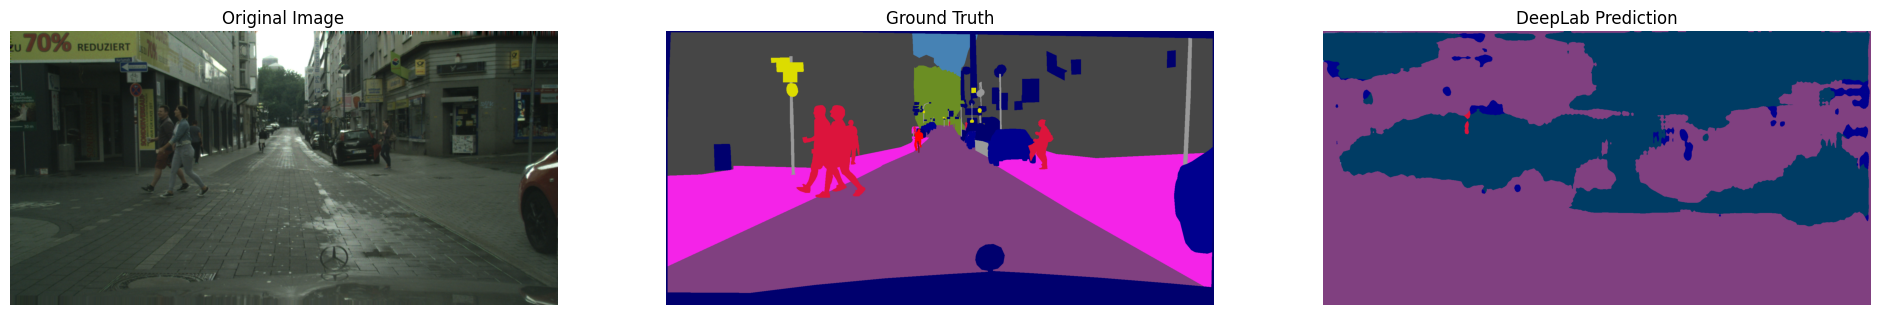

 75%|███████▌  | 17850/23800 [34:00<11:11,  8.86step/s, avg_loss=0.0421, current_loss=0.0242, lr=1.9e-04, mem_gb=3.60, time_s_iter=0.33]

Epoch 6/9 loss: 0.02147639357132502


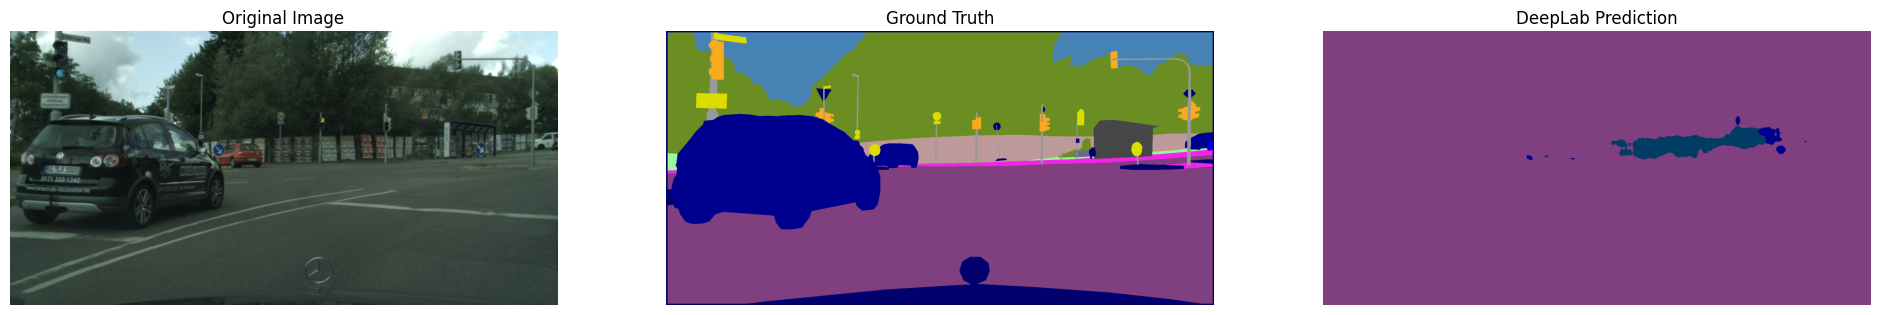

 88%|████████▊ | 20825/23800 [39:40<05:35,  8.86step/s, avg_loss=0.0388, current_loss=0.0161, lr=1.4e-04, mem_gb=3.60, time_s_iter=0.33]

Epoch 7/9 loss: 0.01911169762181128


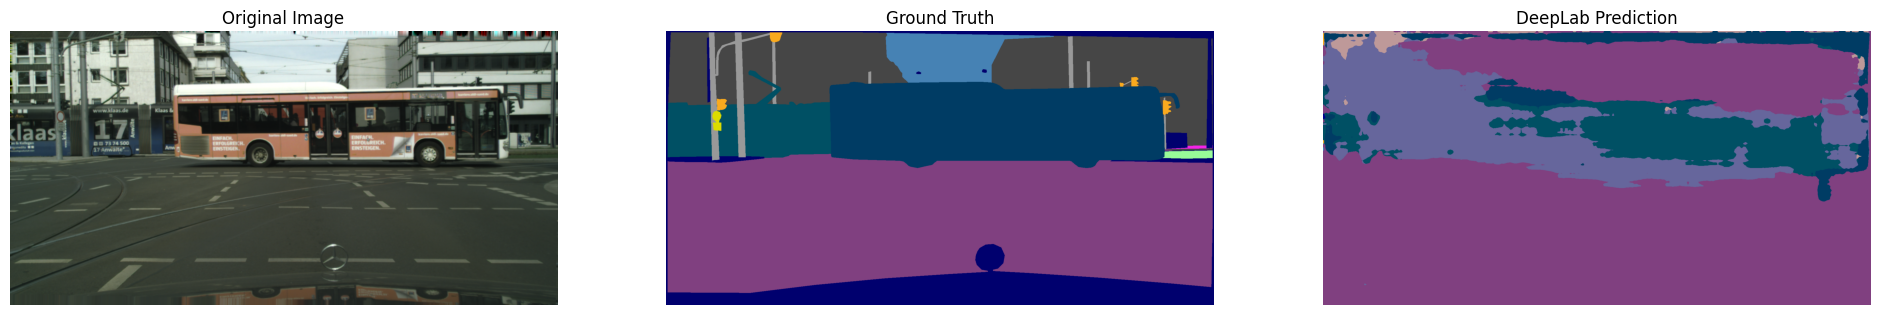

100%|██████████| 23800/23800 [45:21<00:00,  8.84step/s, avg_loss=0.0361, current_loss=0.0288, lr=1.1e-04, mem_gb=3.60, time_s_iter=0.33]

Epoch 8/9 loss: 0.01727478750571433


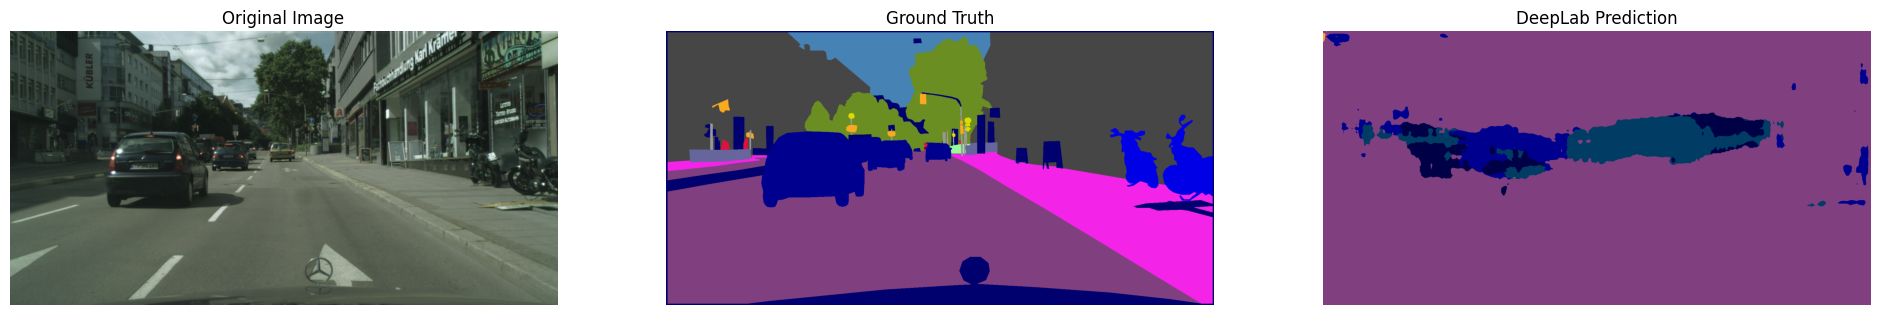

100%|██████████| 23800/23800 [45:22<00:00,  8.74step/s, avg_loss=0.0361, current_loss=0.0288, lr=1.1e-04, mem_gb=3.60, time_s_iter=0.33]



--- Measuring Inference Speed ---
Performing 5 warm-up runs...
Measuring over 100 samples...

--- Training & Inference Summary ---
| train mem (GB)             | 4.77
| train time (s/iter)        | 0.4369
| total train time (hr)      | 0.7563
| inference model time (s/im)| 0.1095
| inference total time (s/im)| 0.1097
------------------------------------



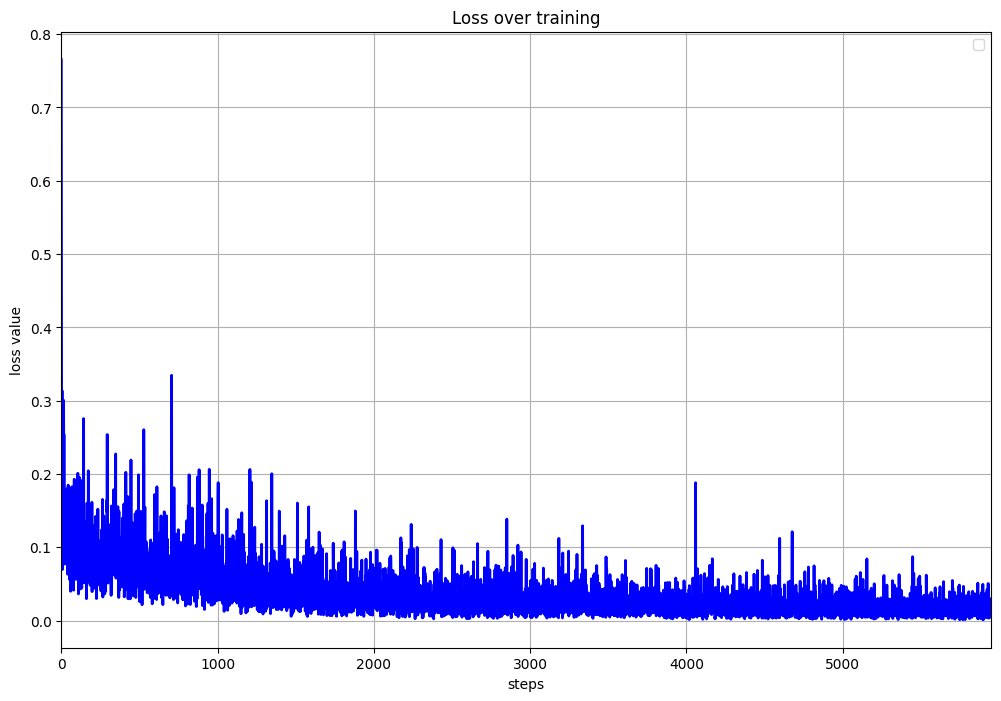

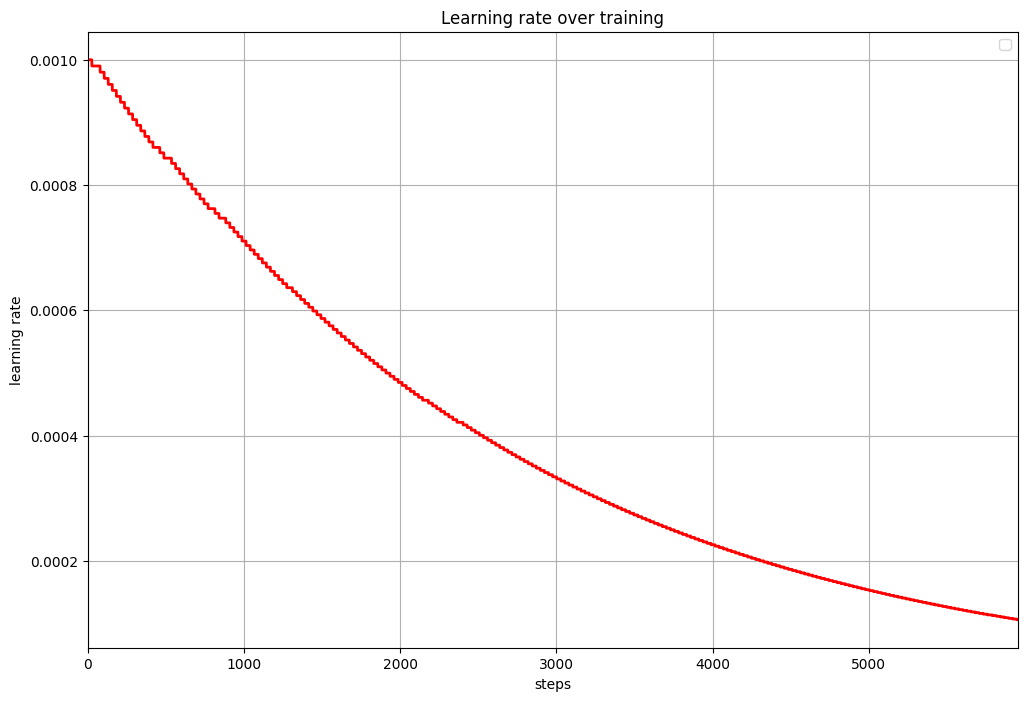

In [27]:
deeplab_model2, _ = train_deeplab_semantic(deeplab_model2, train_dataset, config)

In [34]:

config.model_name = "deeplabv3plus_mobilenet"
config.scaler = 'amp'
config.ckpt_path = "/kaggle/working/"
config.optimizer.params.lr = 1e-3
config.optimizer.params.weight_decay = 1e-4
config.output_stride = 8
config.per_gpu_train_batch_size = 4
config.loss_fn = "cross_entropy"
config.n_epochs = 8
# config.separable_conv = True # plus only
deeplab_model3 = build_model(config, num_classes=19, output_stride=config.output_stride)
train_dataset = CityscapesDataset(config, transform=train_augmentation_deeplab, split='train')
test_dataset_for_viz = CityscapesDataset(config)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 69.4MB/s]


 12%|█▎        | 2975/23800 [06:41<46:35,  7.45step/s, avg_loss=0.9003, current_loss=0.9905, lr=7.6e-04, mem_gb=3.84, time_s_iter=0.39]

Epoch 1/9 loss: 0.9002739350081131


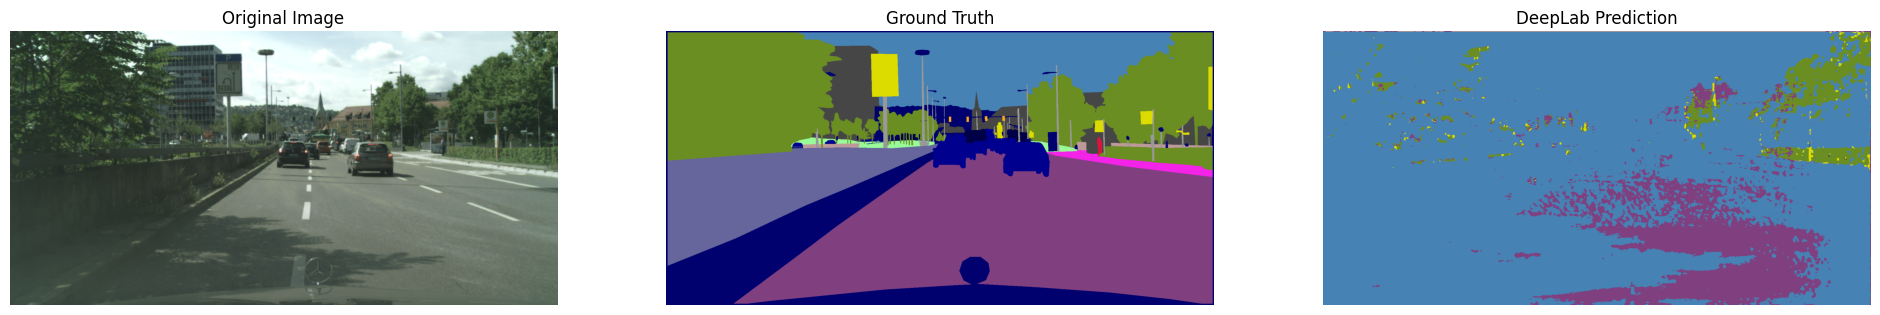

 25%|██▌       | 5950/23800 [13:23<39:50,  7.47step/s, avg_loss=0.8062, current_loss=1.1185, lr=5.8e-04, mem_gb=3.84, time_s_iter=0.39]  

Epoch 2/9 loss: 0.7122075675475982


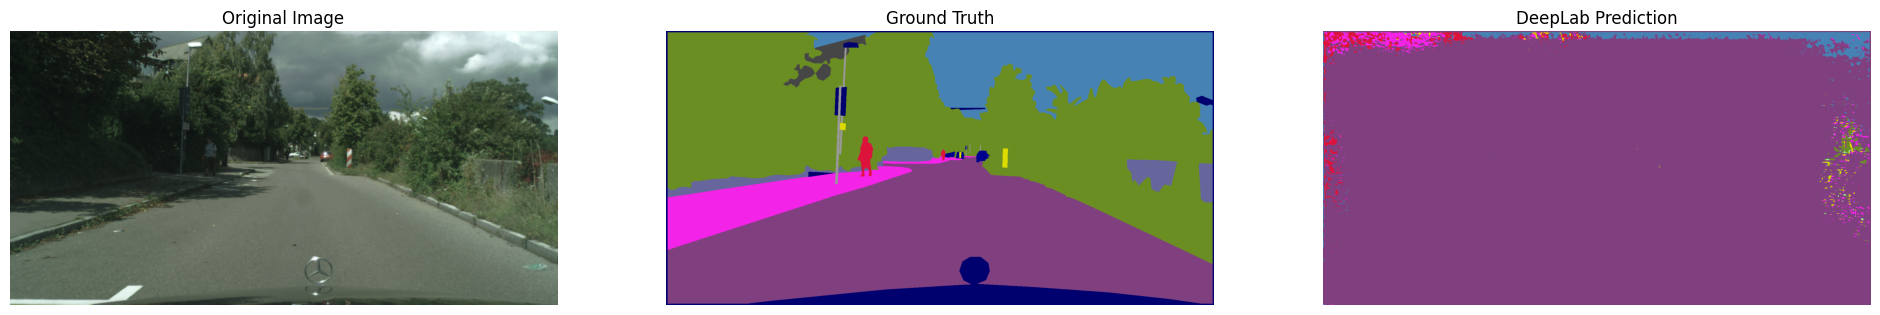

 38%|███▊      | 8925/23800 [20:05<33:14,  7.46step/s, avg_loss=0.7386, current_loss=0.2524, lr=4.3e-04, mem_gb=3.84, time_s_iter=0.39]  

Epoch 3/9 loss: 0.6033242319620424


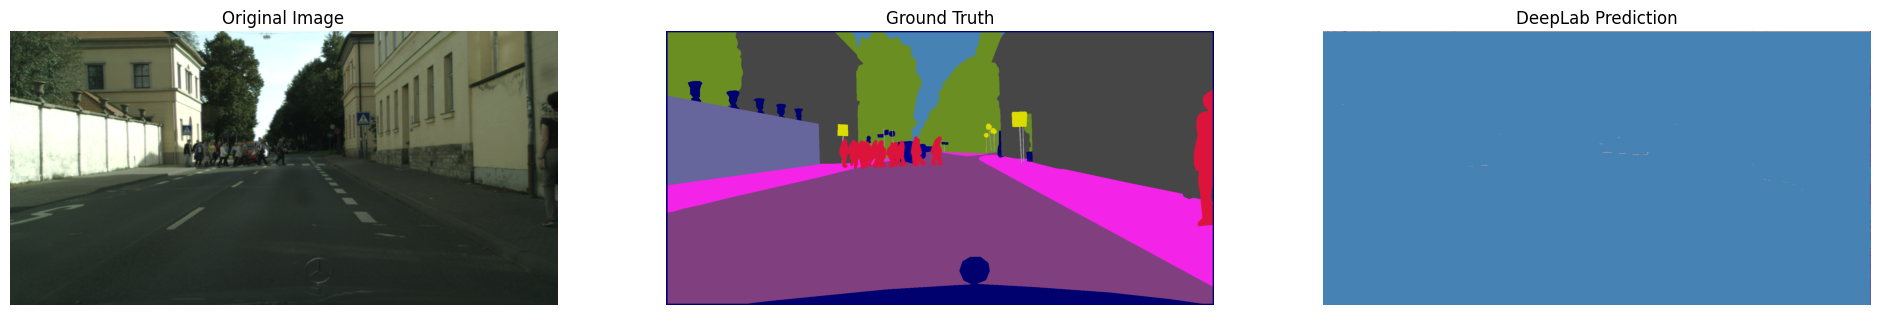

 50%|█████     | 11900/23800 [26:48<26:36,  7.45step/s, avg_loss=0.6888, current_loss=0.8205, lr=3.2e-04, mem_gb=3.84, time_s_iter=0.39] 

Epoch 4/9 loss: 0.5393535235636336


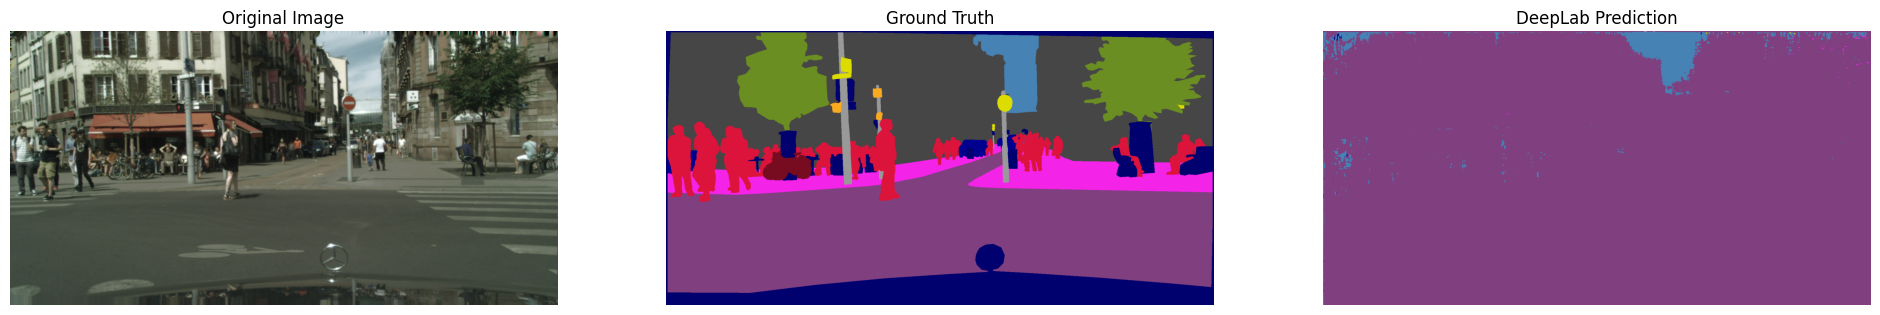

 62%|██████▎   | 14875/23800 [33:30<19:56,  7.46step/s, avg_loss=0.6507, current_loss=0.5474, lr=2.4e-04, mem_gb=3.84, time_s_iter=0.39]  

Epoch 5/9 loss: 0.4981739783198923


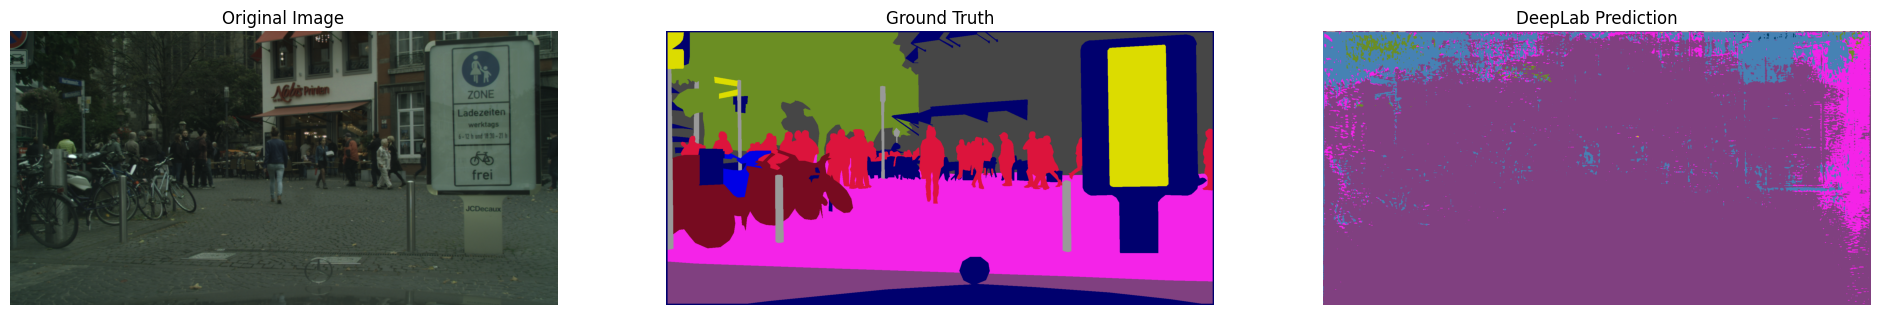

 75%|███████▌  | 17850/23800 [40:12<13:17,  7.46step/s, avg_loss=0.6207, current_loss=0.4031, lr=1.9e-04, mem_gb=3.84, time_s_iter=0.39]

Epoch 6/9 loss: 0.4706387574714358


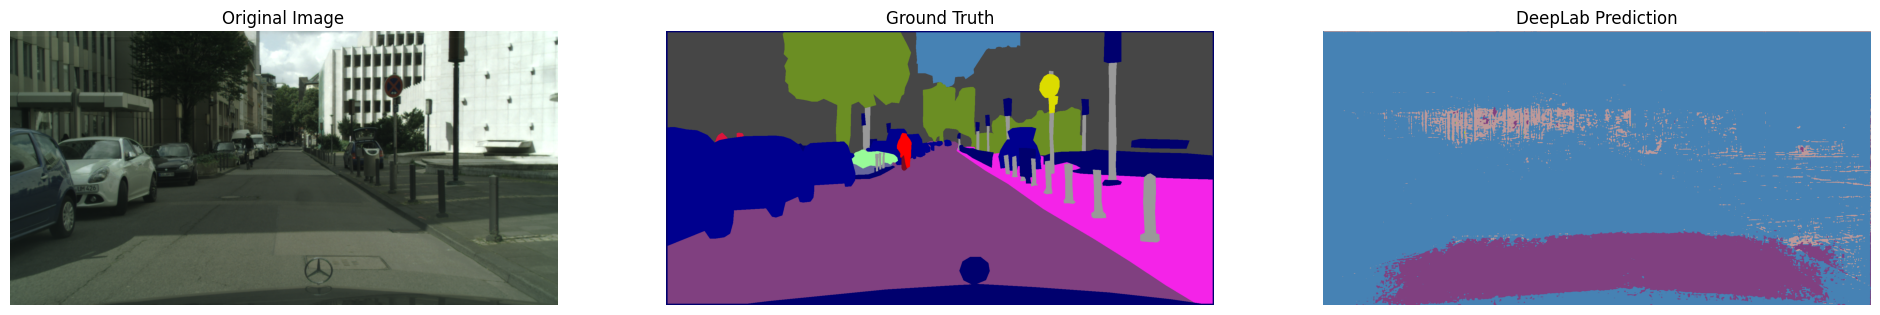

 88%|████████▊ | 20825/23800 [46:54<06:38,  7.46step/s, avg_loss=0.5965, current_loss=0.2936, lr=1.4e-04, mem_gb=3.84, time_s_iter=0.39]

Epoch 7/9 loss: 0.4517468725761739


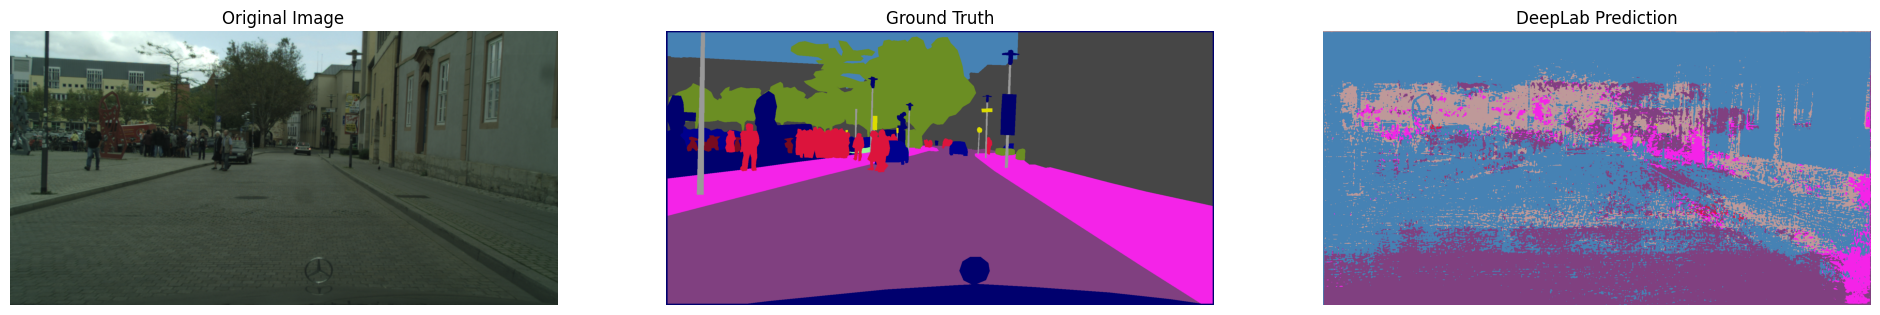

100%|██████████| 23800/23800 [53:37<00:00,  7.46step/s, avg_loss=0.5767, current_loss=0.5640, lr=1.1e-04, mem_gb=3.84, time_s_iter=0.39]

Epoch 8/9 loss: 0.4382685102842828


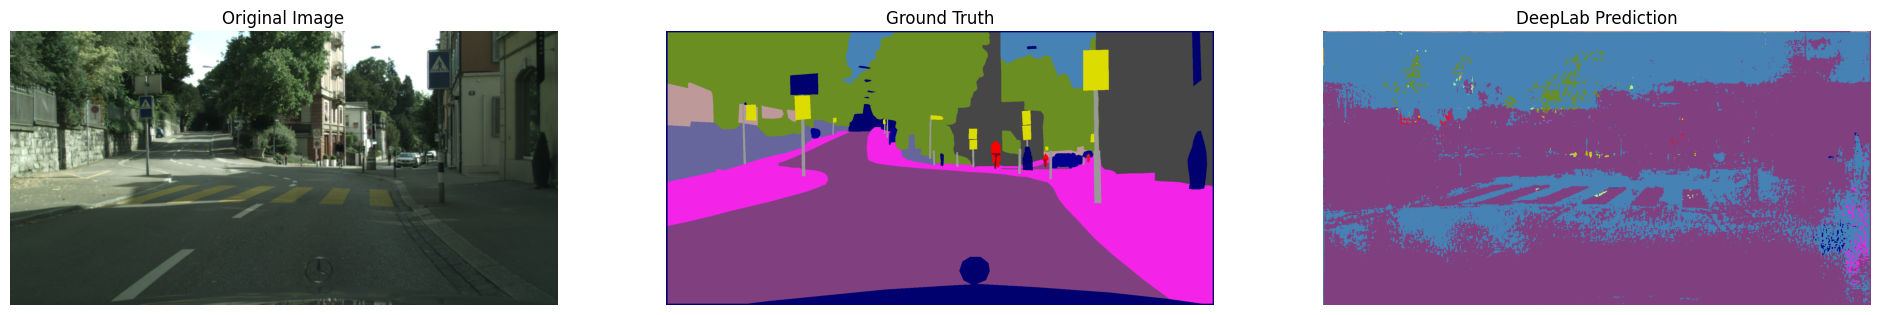

100%|██████████| 23800/23800 [53:39<00:00,  7.39step/s, avg_loss=0.5767, current_loss=0.5640, lr=1.1e-04, mem_gb=3.84, time_s_iter=0.39]



--- Measuring Inference Speed ---
Performing 5 warm-up runs...
Measuring over 100 samples...

--- Training & Inference Summary ---
| train mem (GB)             | 5.02
| train time (s/iter)        | 0.5198
| total train time (hr)      | 0.8942
| inference model time (s/im)| 0.1216
| inference total time (s/im)| 0.1220
------------------------------------



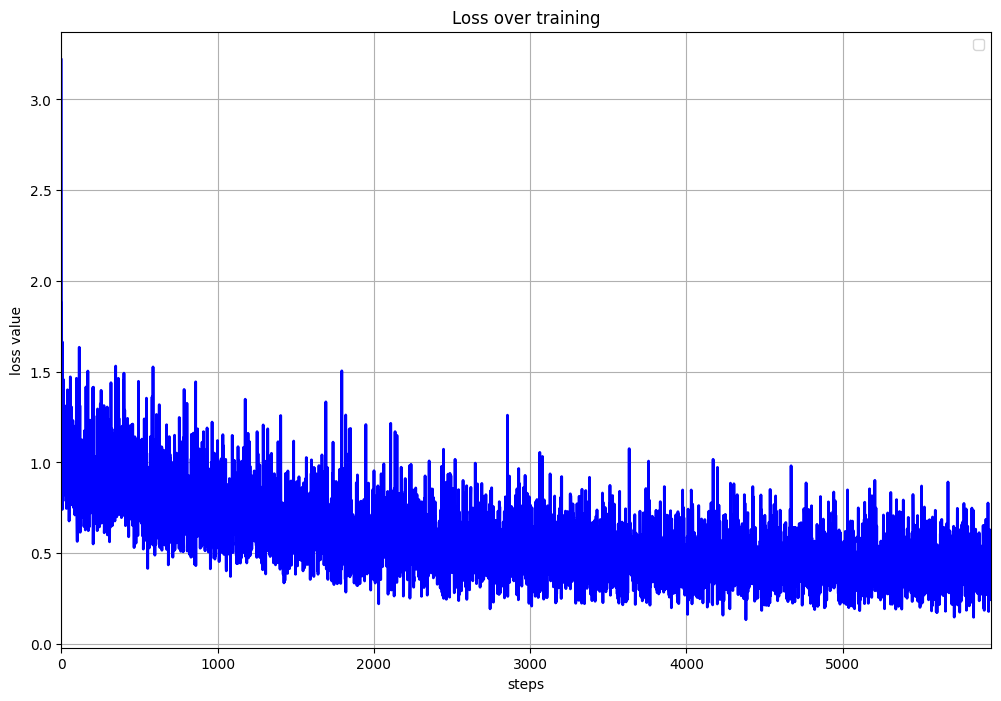

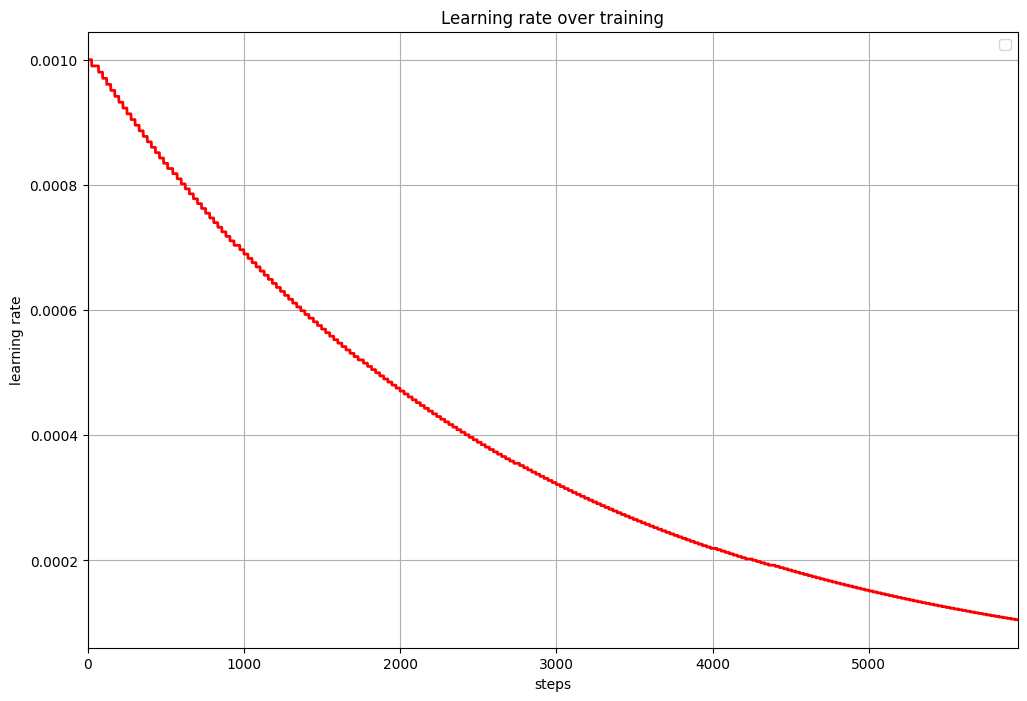

In [35]:
deeplab_model3, _ = train_deeplab_semantic(deeplab_model3, train_dataset, config)

# Validate DeepLabv3

In [25]:
config.model_name = "deeplabv3plus_mobilenet"
config.output_stride = 8
model_ckpt_path = "/kaggle/input/segmentation_cityscapes/pytorch/v01/12/deeplabv3plus_mobilenet_ckpt_8epoch.pth"
deeplab_model = build_model(config, num_classes=19, output_stride=config.output_stride)
weight = torch.load(model_ckpt_path, map_location=torch.device("cpu"))
deeplab_model.load_state_dict(weight['model_state_dict'])
deeplab_model.to(config.device)
print("Load complete")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 210MB/s]


Load complete


In [36]:
deeplab_model = deeplab_model3

In [26]:
import random
def visualize_deeplab(deeplab_model, dataset, class_id_to_name, class_id_to_color, idx=None):
    """
    Loads a sample, runs inference, and displays the original image,
    ground truth mask, and predicted mask side-by-side.
    """
    
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)
    original_image_viz = T.Resize((512, 1024))(decode_image(dataset.images[idx]))
    deeplab_model.eval()

    with torch.no_grad():
        # 1. Get data from the dataset
        image_tensor, target_mask = dataset[idx]
    
        gt_semantic_mask = torch.tensor(target_mask).squeeze(0)
    
        # 2. Prepare image for the model and run inference
        input_tensor = image_tensor.unsqueeze(0).to(config.device)
        logits = deeplab_model(input_tensor)
        
        # 3. Process the prediction: Use argmax (this part was already correct)
        pred_semantic_mask = torch.argmax(logits.squeeze(0), dim=0).cpu()
    
    # Colorize the ground truth and prediction masks
    gt_color_mask = colorize_mask(gt_semantic_mask, class_id_to_color)
    pred_color_mask = colorize_mask(pred_semantic_mask, class_id_to_color)
    
    # 5. Display the results
    plt.figure(figsize=(24, 8))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original_image_viz.permute(1, 2, 0))
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt_color_mask.permute(1, 2, 0))
    plt.title("Ground Truth")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_color_mask.permute(1, 2, 0))
    plt.title("DeepLab Prediction")
    plt.axis('off')
    
    plt.show()
    deeplab_model.train()

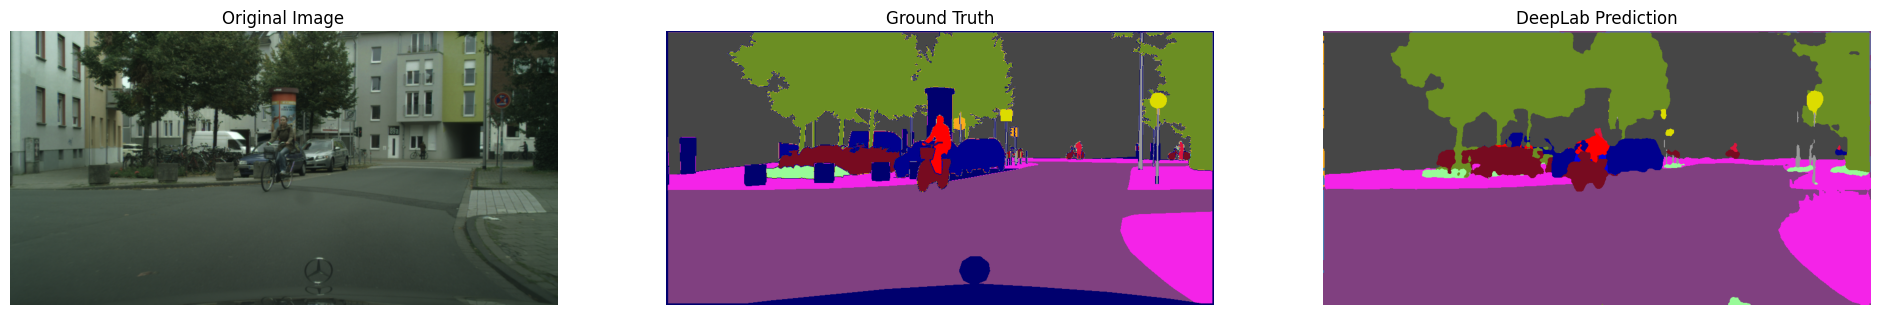

In [29]:
test_dataset_for_viz = CityscapesDataset(path_cfg, transform=val_augmentation_deeplab, split='val')
visualize_deeplab(deeplab_model, test_dataset_for_viz, class_id_to_name_19c, class_id_to_color_19c)

In [30]:
class CustomMeanIoU:
    def __init__(self, num_classes: int, ignore_index: int = None, device: torch.device = None):
        """
        Custom MeanIoU metric that explicitly handles an ignore_index.

        Args:
            num_classes (int): The number of valid classes (excluding the ignore_index).
            ignore_index (int, optional): The class label to ignore in calculations. Defaults to None.
            device (torch.device, optional): The device to store internal tensors on. Defaults to None (CPU).
        """
        if num_classes <= 0:
            raise ValueError("num_classes must be a positive integer.")
        
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.device = device if device is not None else torch.device("cpu")

        self.intersections = torch.zeros(num_classes, dtype=torch.long, device=self.device)
        self.unions = torch.zeros(num_classes, dtype=torch.long, device=self.device)
        
        self._num_updates = 0

    def update(self, preds: torch.Tensor, target: torch.Tensor):
        """
        Update the metric state with new predictions (logits) and targets (one-hot masks).

        Args:
            preds (torch.Tensor): Predicted mask logits (float tensor, shape [B, C, H, W]).
            target (torch.Tensor): Ground truth semantic masks (long/float tensor, shape [B, C, H, W] - assumed one-hot or similar).
                                   Values should represent class membership.
                                   If target is already class IDs [B, H, W], please adjust this function.
        """
        # --- 1. Convert logits to predicted class IDs [B, H, W] ---
        if preds.dim() != 4:
            raise ValueError(f"Preds must be [B, C, H, W] where C is num_classes. Got {preds.shape}")
        predicted_classes = torch.argmax(preds, dim=1).to(torch.long)

        # --- 2. Convert target from multi-channel (e.g., one-hot) to class IDs [B, H, W] ---
        if target.dim() == 4:
            if target.shape[1] != 1:
                target_classes = torch.argmax(target, dim=1).clone().to(torch.long)
            else:
                target_classes = target.squeeze(1).clone().to(torch.long) # Added .clone() for safety
        elif target.dim() == 3:
            target_classes = target.clone().to(torch.long)
        else:
            raise ValueError(
                f"Unsupported target shape or format. Expected [B, C, H, W] (one-hot), "
                f"[B, 1, H, W], or [B, H, W] (class IDs). Got {target.shape}"
            )

        if predicted_classes.shape != target_classes.shape:
            raise ValueError(
                f"Predicted and target class maps must have the same spatial shape. "
                f"Got predicted: {predicted_classes.shape} and target: {target_classes.shape}"
            )
        
        predicted_classes = predicted_classes.to(self.device)
        target_classes = target_classes.to(self.device)

        valid_mask = torch.ones_like(target_classes, dtype=torch.bool, device=self.device)
        if self.ignore_index is not None:
            valid_mask = (target_classes != self.ignore_index)

        preds_valid = predicted_classes[valid_mask]
        target_valid = target_classes[valid_mask]
        
        for c in range(self.num_classes):
            target_c = (target_valid == c)
            preds_c = (preds_valid == c)

            intersection = (preds_c & target_c).sum()
            union = (preds_c | target_c).sum()

            self.intersections[c] += intersection
            self.unions[c] += union
            
        self._num_updates += preds.shape[0]

    def compute(self) -> float:
        """
        Compute the Mean IoU based on accumulated intersections and unions.

        Returns:
            float: The Mean IoU value. Returns 0.0 if no valid pixels were processed.
        """
        ious = torch.zeros(self.num_classes, dtype=torch.float, device=self.device)

        for c in range(self.num_classes):
            if self.unions[c] > 0:
                ious[c] = self.intersections[c].float() / self.unions[c].float()
            else:
                # If a class had no ground truth or predictions in valid regions, its IoU is NaN
                # We will ignore these NaNs when computing the mean.
                ious[c] = torch.nan 

        # Filter out NaN values (classes with no occurrences) for mean calculation
        valid_ious = ious[~torch.isnan(ious)]
        # print(ious)
        if len(valid_ious) == 0:
            return 0.0
            
        mean_iou = torch.mean(valid_ious)
        return mean_iou.item()

    def reset(self):
        """
        Reset the metric state.
        """
        self.intersections = torch.zeros(self.num_classes, dtype=torch.long, device=self.device)
        self.unions = torch.zeros(self.num_classes, dtype=torch.long, device=self.device)
        self._num_updates = 0



# Original: https://github.com/matterport/Mask_RCNN
def compute_overlaps_masks(masks1, masks2):
    """Computes IoU overlaps between two sets of masks.
    masks1, masks2: [Height, Width, instances]
    """
    
    # If either set of masks is empty return empty result
    if masks1.shape[-1] == 0 or masks2.shape[-1] == 0:
        return np.zeros((masks1.shape[-1], masks2.shape[-1]))
        
    # flatten masks and compute their areas
    masks1 = np.reshape(masks1 > .5, (-1, masks1.shape[-1])).astype(np.float32)
    masks2 = np.reshape(masks2 > .5, (-1, masks2.shape[-1])).astype(np.float32)
    area1 = np.sum(masks1, axis=0)
    area2 = np.sum(masks2, axis=0)
    # intersections and union
    intersections = np.dot(masks1.T, masks2)
    union = area1[:, None] + area2[None, :] - intersections
    overlaps = intersections / union
    
    return overlaps

# Original: https://github.com/matterport/Mask_RCNN
def trim_zeros(x):
    """It's common to have tensors larger than the available data and
    pad with zeros. This function removes rows that are all zeros.

    x: [rows, columns].
    """
    assert len(x.shape) == 2
    return x[~np.all(x == 0, axis=1)]
    
# Original: https://github.com/matterport/Mask_RCNN
def compute_matches(gt_boxes, gt_class_ids, gt_masks,
                    pred_boxes, pred_class_ids, pred_scores, pred_masks,
                    iou_threshold=0.5, score_threshold=0.1): # low score threshold
    """Finds matches between prediction and ground truth instances.

    Returns:
        gt_match: 1-D array. For each GT box it has the index of the matched
                  predicted box.
        pred_match: 1-D array. For each predicted box, it has the index of
                    the matched ground truth box.
        overlaps: [pred_boxes, gt_boxes] IoU overlaps.
    """
    # Trim zero padding
    # TODO: cleaner to do zero unpadding upstream
    # gt_boxes = trim_zeros(gt_boxes)
    gt_masks = gt_masks[..., :gt_boxes.shape[0]]
    # pred_boxes = trim_zeros(pred_boxes)
    pred_scores = pred_scores[:pred_boxes.shape[0]]
    # Sort predictions by score from high to low
    indices = np.argsort(pred_scores)[::-1].copy()
    pred_boxes = pred_boxes[indices]
    pred_class_ids = pred_class_ids[indices]
    pred_scores = pred_scores[indices]
    pred_masks = pred_masks[..., indices]

    # Compute IoU overlaps [pred_masks, gt_masks]
    overlaps = compute_overlaps_masks(pred_masks, gt_masks)
    # print(overlaps.shape)
    # plt.figure(figsize=(15, 18))
    # plt.imshow(overlaps, interpolation='nearest', cmap=plt.cm.Blues)
    # plt.colorbar()
    
    # tick_marks_gt = np.arange(len(gt_class_ids))
    # tick_marks = np.arange(len(pred_class_ids))
    # plt.xticks(tick_marks_gt, gt_class_ids, rotation=45)
    # plt.yticks(tick_marks, pred_class_ids)
    
    # # Adding text annotations
    # for i in range(overlaps.shape[0]):
    #     for j in range(overlaps.shape[1]):
    #         plt.text(j, i, format(overlaps[i, j], 'f'),
    #                  horizontalalignment="center",
    #                  color="white" if overlaps[i, j] > overlaps.max() / 2 else "black")
    
    # plt.ylabel('Predicted Label')
    # plt.xlabel('True Label')
    # plt.tight_layout()
    # plt.show()

    # Loop through predictions and find matching ground truth boxes
    match_count = 0
    pred_match = -1 * np.ones([pred_boxes.shape[0]])
    gt_match = -1 * np.ones([gt_boxes.shape[0]])
    for i in range(len(pred_boxes)):
        # Find best matching ground truth box
        # 1. Sort matches by score
        sorted_ixs = np.argsort(overlaps[i])[::-1]
        # 2. Remove low scores
        low_score_idx = np.where(overlaps[i, sorted_ixs] < score_threshold)[0]
        if low_score_idx.size > 0:
            sorted_ixs = sorted_ixs[:low_score_idx[0]]
        # 3. Find the match
        for j in sorted_ixs:
            # If ground truth box is already matched, go to next one
            if gt_match[j] > -1:
                continue
            # If we reach IoU smaller than the threshold, end the loop
            iou = overlaps[i, j]
            if iou < iou_threshold:
                break
            # Do we have a match?
            if pred_class_ids[i] == gt_class_ids[j]:
                match_count += 1
                gt_match[j] = i
                pred_match[i] = j
                break

    return gt_match, pred_match, overlaps


# Original: https://github.com/matterport/Mask_RCNN
def compute_ap(gt_boxes, gt_class_ids, gt_masks,
               pred_boxes, pred_class_ids, pred_scores, pred_masks,
               iou_threshold=0.5):
    """Compute Average Precision at a set IoU threshold (default 0.5).
    gt_boxes, pred_boxes : (N, 4)
    gt_class_ids, pred_class_ids : (N)
    gt_masks, pred_masks : (H, W, N)

    Returns:
    mAP: Mean Average Precision
    precisions: List of precisions at different class score thresholds.
    recalls: List of recall values at different class score thresholds.
    overlaps: [pred_boxes, gt_boxes] IoU overlaps.
    """
    # Get matches and overlaps
    gt_match, pred_match, overlaps = compute_matches(
        gt_boxes, gt_class_ids, gt_masks,
        pred_boxes, pred_class_ids, pred_scores, pred_masks,
        iou_threshold)

    # Compute precision and recall at each prediction box step
    precisions = np.cumsum(pred_match > -1) / (np.arange(len(pred_match)) + 1)
    recalls = np.cumsum(pred_match > -1).astype(np.float32) / len(gt_match)

    # Pad with start and end values to simplify the math
    precisions = np.concatenate([[0], precisions, [0]])
    recalls = np.concatenate([[0], recalls, [1]])
    # Ensure precision values decrease but don't increase. This way, the
    # precision value at each recall threshold is the maximum it can be
    # for all following recall thresholds, as specified by the VOC paper.
    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = np.maximum(precisions[i], precisions[i + 1])

    # Compute mean AP over recall range
    indices = np.where(recalls[:-1] != recalls[1:])[0] + 1
    mAP = np.sum((recalls[indices] - recalls[indices - 1]) *
                 precisions[indices])

    return mAP, precisions, recalls, overlaps

# Original: https://github.com/matterport/Mask_RCNN
def compute_ap_range(gt_box, gt_class_id, gt_mask,
                     pred_box, pred_class_id, pred_score, pred_mask,
                     iou_thresholds=None, verbose=1):
    """Compute AP over a range or IoU thresholds. Default range is 0.5-0.95."""
    # Default is 0.5 to 0.95 with increments of 0.05
    iou_thresholds = iou_thresholds or np.arange(0.5, 1.0, 0.05)
    
    # Compute AP over range of IoU thresholds
    AP = []
    for iou_threshold in iou_thresholds:
        ap, precisions, recalls, overlaps =\
            compute_ap(gt_box, gt_class_id, gt_mask,
                        pred_box, pred_class_id, pred_score, pred_mask,
                        iou_threshold=iou_threshold)
        if verbose:
            print("AP @{:.2f}:\t {:.3f}".format(iou_threshold, ap))
        AP.append(ap)
    AP = np.array(AP).mean()
    if verbose:
        print("AP @{:.2f}-{:.2f}:\t {:.3f}".format(
            iou_thresholds[0], iou_thresholds[-1], AP))
    return AP

In [31]:
def evaluate_deeplab_model(model, dataloader, device, num_classes, mIoU_metric):
    """
    Correctly evaluates a DeepLabv3 model using CustomMeanIoU, ignoring the class index 255.
    """
    print('Evaluating DeepLabv3 model with CustomMeanIoU...')
    model.eval()

    cnt = 0
    mAP = 0.0
    mAP50 = 0.0
    
    with torch.no_grad():
        with tqdm(desc="Evaluating DeepLabv3", total=len(dataloader), leave=False) as pbar:
            for images, targets in dataloader:
                images = images.to(device, dtype=torch.float32) # [B, 3, H, W]
                semantic_masks = targets.squeeze(1)
                cnt += len(images)     
                
                predicted_masks = model(images) # [B, 19, H, W]
                
                # ===================================================== Calculate mIoU ====================================================
                onehot_masks = torch.zeros((semantic_masks.shape[0], num_classes, semantic_masks.shape[1], semantic_masks.shape[2]), dtype=torch.long)
                for i in range(semantic_masks.shape[0]):
                    unique_classes_in_this_mask = torch.unique(semantic_masks[i])
                    for class_id in range(num_classes):
                        if class_id in unique_classes_in_this_mask:
                            onehot_masks[i, class_id, :, :] = (semantic_masks[i] == class_id).long()

                mIoU_metric.update(predicted_masks.long().cpu(), onehot_masks.long().cpu())

                # ===================================================== Calculate mAP =====================================================
                dummy_boxes = np.zeros((num_classes, 4)) # dummy mAP doesnt process what inside
                dummy_scores = np.full(num_classes, 1.0) # assume model is sure about the mask
                pred_labels = np.arange(num_classes)
                for i in range(len(predicted_masks)):
                    # target_mask = targets[i] # (1, H, W)
                    onehot_partial_masks = []
                    target_labels = np.unique(targets[i])[:-1]
                    for class_id in target_labels:
                        onehot_partial_masks.append((semantic_masks[i] == class_id).long())
                    onehot_partial_masks = np.array(onehot_partial_masks).transpose(1, 2, 0)
                    pred_masks = (predicted_masks[i] > 0.5).to('cpu').permute(1, 2, 0)
                    pred_masks = np.array(pred_masks)
                    # print(target_labels)
                    # print(target_labels.shape, onehot_partial_masks.shape)
                    
                    mAP50 += compute_ap_range(dummy_boxes, target_labels, onehot_partial_masks,
                                        dummy_boxes, pred_labels, dummy_scores, pred_masks,
                                        iou_thresholds=[0.5], verbose=0)
                    
                    mAP += compute_ap_range(dummy_boxes, target_labels, onehot_partial_masks,
                                        dummy_boxes, pred_labels, dummy_scores, pred_masks,
                                        iou_thresholds=None, verbose=0)
                
                
                pbar.update(1)
                pbar.set_postfix(iou=f"{mIoU_metric.compute():.4f}", mAP50=f"{mAP50/cnt:.4f}", mAP=f"{mAP/cnt:.4f}")
                # if cnt >= 8:
                #     break

    val_miou = mIoU_metric.compute()
    mAP50 /= cnt
    mAP /= cnt
    model.train()
    return val_miou, mAP50, mAP

In [32]:

# mIoU_metric = MeanIoU(num_classes=20, include_background=False)
num_classes = 19

val_dataset = CityscapesDataset(config, transform=val_augmentation_deeplab, split='val')
val_dataloader = get_dataloader(val_dataset, config, is_train=False)

mIoU_metric = CustomMeanIoU(num_classes=num_classes, ignore_index=255, device=config.device)
val_miou, val_mAP50, val_mAP = evaluate_deeplab_model(deeplab_model, val_dataloader, config.device, num_classes, mIoU_metric)
print(val_miou, val_mAP50, val_mAP)

Evaluating DeepLabv3 model with CustomMeanIoU...


0.47356605529785156 0.03208176868482046 0.008984151894639613
